# Deep Learning Day 1: From Machine Learning to Neural Networks

## Learning Objectives

By the end of this lecture, you will:
- Understand the difference between traditional ML and Deep Learning
- Build a perceptron from scratch and understand how it makes decisions
- Know the key activation functions (step, sigmoid, ReLU, softmax)
- Understand forward propagation through a neural network
- Build your first neural network with TensorFlow/Keras

## Why This Matters

Every AI tool you use daily - ChatGPT, image recognition, voice assistants - is powered by neural networks. Today we bridge from the ML algorithms you already know to the deep learning that powers modern AI.

---

## Setup

In [2]:
# Libraries you already know from previous weeks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Setup complete!")

Matplotlib is building the font cache; this may take a moment.


Setup complete!


---

# Part 1: From Machine Learning to Deep Learning

Before diving into neural networks, let's understand **WHY** we need them and **HOW** they differ from what you've learned.

## Quick Review: What You Already Know

Over the past days, you learned several ML algorithms:

| Algorithm | How it Decides | Key Idea |
|-----------|---------------|----------|
| Logistic Regression | Weighted sum → Sigmoid → Threshold | Linear boundary |
| Decision Tree | Series of if/else questions | Split by features |
| KNN | Find K nearest neighbors, vote | Distance-based |
| SVM | Find maximum margin boundary | Support vectors |
| Random Forest | Many trees vote together | Ensemble |

**The key insight:** All these algorithms learn a **mapping** from inputs (features) to outputs (predictions).

```
INPUT FEATURES              →  ML ALGORITHM  →  OUTPUT PREDICTION
[age, sex, fare, pclass]    →  LogReg/Tree   →  [survived: 0 or 1]
```

**But notice something important:** YOU had to decide which features to use (age, sex, fare, pclass).

This is called **feature engineering**, and it's both:
- The most important part of ML (good features = good model)
- The hardest and most time-consuming part (requires domain expertise)

---

## The Problem: What About Images, Text, Audio?

Traditional ML works great for **tabular data** (spreadsheets with rows and columns).

But what if you want to classify **images**?

```
THE CHALLENGE: Classify this image as "cat" or "dog"

    Image (28x28 pixels):                What features would YOU choose?
    
    ████████████████████                 - Average brightness?
    ██░░░░░░░░░░░░░░░░██                 - Number of edges?
    ██░░████░░░░████░░██                 - Color histogram?
    ██░░████░░░░████░░██                 - ???
    ██░░░░░░████░░░░░░██                 
    ██░░░░████████░░░░██                 This is REALLY HARD!
    ██░░░░░░░░░░░░░░░░██                 What makes a "cat" a cat?
    ████████████████████                 
```

**The problem:** For images, text, and audio:
- We don't know what the "right" features are
- Hand-crafting features takes months of expert work
- Human-chosen features often miss important patterns

**This is where Deep Learning shines!**

---

## What is Deep Learning?

### The Simple Answer

**Deep Learning = Machine Learning using Neural Networks with multiple layers**

That's it. It's not magic - it's still finding patterns in data.

### The Key Difference: Automatic Feature Learning

```
TRADITIONAL ML (what you learned):
┌─────────────────────────────────────────────────────────────────────────┐
│  Raw Data  →  [Human Feature Engineering]  →  Features  →  [Model]  →  Prediction │
│                        ↑                                                │
│                  YOU do this!                                           │
│            (select: age, sex, fare...)                                  │
└─────────────────────────────────────────────────────────────────────────┘

DEEP LEARNING:
┌─────────────────────────────────────────────────────────────────────────┐
│  Raw Data  →  [Neural Network learns features AND makes predictions]  →  Prediction │
│                        ↑                                                │
│               NETWORK does this automatically!                          │
│            (learns edges, shapes, patterns...)                          │
└─────────────────────────────────────────────────────────────────────────┘
```

### Concrete Example: Cat vs Dog Classification

**Traditional ML approach:**
1. Hire an expert to define features (takes months!)
2. Expert might choose: ear shape ratio, nose size, fur texture, ...
3. Write code to extract these features from each image
4. Feed features to Logistic Regression or SVM
5. Hope your features capture what makes a cat a cat!

**Deep Learning approach:**
1. Feed raw pixel values directly to neural network
2. Network automatically learns: "edges in certain positions = ear"
3. Then learns: "these ear shapes + this nose = cat"
4. No manual feature engineering needed!

```
DEEP LEARNING FOR IMAGES:

Layer 1 learns:      Layer 2 learns:       Layer 3 learns:       Output:
Simple edges         Shapes                Parts                 Class
   |  /  \  _          ○  □  △             👁️  👃  👂           🐱 or 🐕
   
Raw pixels → Edges → Shapes → Object parts → "It's a cat!"
```

---

### When to Use What?

| Use Traditional ML when... | Use Deep Learning when... |
|---------------------------|---------------------------|
| You have structured/tabular data | You have images, text, audio |
| Small to medium datasets (<100K) | Large datasets (millions of examples) |
| You need interpretability | Performance matters most |
| Limited compute (no GPU) | You have GPUs available |
| Features are well-defined | Features are complex/unknown |

**Important:** Deep learning is NOT always better!
- For Titanic survival prediction, Logistic Regression is probably fine
- For classifying 10 million images, you need deep learning

---

## The Bridge: Logistic Regression IS a Neural Network!

We've been talking about neural networks as if they're something completely new. But here's a secret that connects everything together:

**Logistic Regression - which you already know - is actually the simplest neural network!** (with no hidden layers)

```
WHY DOES THIS MATTER?

You already understand:
    • Weighted sum: w1*x1 + w2*x2 + ... + bias
    • Sigmoid activation: convert to probability
    • Training: adjust weights to minimize error

These are EXACTLY the building blocks of neural networks!

The only difference:
    Logistic Regression = 1 layer (input → output)
    Neural Network = multiple layers (input → hidden → output)
```

Let's visualize this connection:

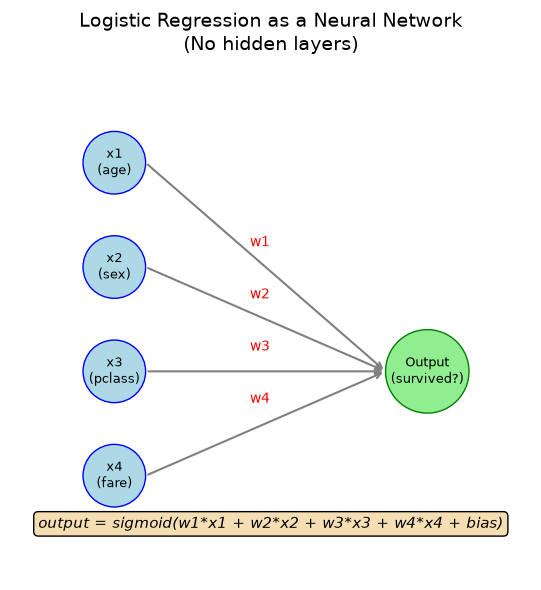

This IS a neural network - just the simplest one possible!
Deep learning = adding more layers between input and output


In [3]:
# What you learned: Logistic Regression
# score = w1*x1 + w2*x2 + ... + wn*xn + bias
# probability = sigmoid(score)
# prediction = 1 if probability > 0.5 else 0

# Visualize this as a "network"
fig, ax = plt.subplots(figsize=(12, 6))

# Draw input nodes
inputs = ['x1\n(age)', 'x2\n(sex)', 'x3\n(pclass)', 'x4\n(fare)']
for i, inp in enumerate(inputs):
    circle = plt.Circle((1, 4-i), 0.3, color='lightblue', ec='blue')
    ax.add_patch(circle)
    ax.text(1, 4-i, inp, ha='center', va='center', fontsize=9)

# Draw output node
circle = plt.Circle((4, 2), 0.4, color='lightgreen', ec='green')
ax.add_patch(circle)
ax.text(4, 2, 'Output\n(survived?)', ha='center', va='center', fontsize=9)

# Draw connections (weights)
weights = ['w1', 'w2', 'w3', 'w4']
for i in range(4):
    ax.annotate('', xy=(3.6, 2), xytext=(1.3, 4-i),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(2.3, 3.2-i*0.5, weights[i], fontsize=10, color='red')

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Logistic Regression as a Neural Network\n(No hidden layers)', fontsize=14)

# Add formula
ax.text(2.5, 0.5, 'output = sigmoid(w1*x1 + w2*x2 + w3*x3 + w4*x4 + bias)',
        ha='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print("This IS a neural network - just the simplest one possible!")
print("Deep learning = adding more layers between input and output")

---

# Part 2: The Perceptron - The Building Block

We just saw that Logistic Regression is basically a neural network with no hidden layers. Now let's zoom in on the **single unit** that makes up all neural networks: the **perceptron**.

## Inspiration: The Biological Neuron

Neural networks are inspired by how your brain works (loosely!).

```
BIOLOGICAL NEURON:                          ARTIFICIAL NEURON (Perceptron):

    dendrites                                     inputs
    (receive signals)                             (x1, x2, x3)
         │ │ │                                        │ │ │
         ▼ ▼ ▼                                        ▼ ▼ ▼
    ┌─────────────┐                              ┌─────────────┐
    │   cell body │                              │   weighted  │
    │   (soma)    │  ──────►                     │     sum     │  ──────►
    │ integrates  │    axon                      │   + bias    │   activation
    │   signals   │  (output)                    │             │    function
    └─────────────┘                              └─────────────┘
                                                       │
    If total signal > threshold,                       ▼
    neuron "fires"                                  OUTPUT

BRAIN: ~86 billion neurons                   NEURAL NETWORK: thousands to billions
       connected in complex ways              of artificial neurons in layers
```

**Key insight:** A single neuron does a simple computation:
1. Receives multiple inputs
2. Combines them (weighted sum)
3. Decides whether to "fire" (activation)

Let's build this step by step!

---

## What is a Perceptron?

A **perceptron** is the simplest possible artificial neuron. It does exactly 3 things:

### Step 1: Weighted Sum

Each input has a **weight** that determines its importance:

```
    INPUT          WEIGHT         CONTRIBUTION
    ──────         ──────         ────────────
    x1 = 3    ×    w1 = 2    =        6
    x2 = 1    ×    w2 = -1   =       -1
    x3 = 4    ×    w3 = 0.5  =        2
                               ─────────────
    Weighted Sum =                   7
```

**Formula:** `z = (x1 × w1) + (x2 × w2) + (x3 × w3)`

**Intuition:**
- Large positive weight = this input is VERY important for a positive output
- Large negative weight = this input pushes toward negative output
- Weight near zero = this input doesn't matter much

### Step 2: Add Bias

The **bias** shifts the decision threshold:

```
z = (x1 × w1) + (x2 × w2) + (x3 × w3) + bias

Without bias (bias = 0):        With bias = -5:
Must cross at origin            Can shift the threshold!

         │                              │
         │  /                           │  /
    ─────┼────                     ─────┼────
         │                              │
                                   ───────────
                                    shifted down by 5
```

### Step 3: Activation Function

Convert the weighted sum into a final output:

```
           INPUTS         WEIGHTS        
              │              │            
              ▼              ▼            
    x1 ──────(w1)──┐                      
                   │                      
    x2 ──────(w2)──┼──► [Σ + bias] ──► [Activation] ──► OUTPUT
                   │                      
    x3 ──────(w3)──┘                      

    Weighted Sum = (x1 × w1) + (x2 × w2) + (x3 × w3) + bias
    Output = Activation(Weighted Sum)
```

**This is exactly what Logistic Regression does!**
- Weighted sum + bias = linear combination
- Sigmoid activation = convert to probability

The difference between neural network "neurons" is which **activation function** they use.

---

## Activation Functions: The Decision Makers

We just learned that a perceptron has three steps: weighted sum → add bias → **activation function**.

We glossed over that last step. But the activation function is actually the **most important part** - it's what gives neural networks their power!

**WHY do we need activation functions?**

Without an activation function, a neural network is just a bunch of linear equations stacked together. And mathematically, stacking linear equations gives you... another linear equation!

```
WITHOUT ACTIVATION (just linear):
Layer 1: y = 2x + 1
Layer 2: z = 3y + 2 = 3(2x + 1) + 2 = 6x + 5

Two layers collapse into ONE linear equation!
Adding more layers does nothing useful!

WITH ACTIVATION (non-linear):
Layer 1: y = ReLU(2x + 1)   ← non-linear!
Layer 2: z = 3y + 2

Now we can learn complex, curvy patterns!
```

**Bottom line:** Activation functions let neural networks learn non-linear patterns (curves, not just straight lines).

There are several activation functions, each with its own purpose. Let's explore them from oldest to newest:

---

### 1. Step Function (The Original - 1950s)

The simplest activation - like a light switch: either ON (1) or OFF (0).

```
STEP FUNCTION:

Output │
   1   │         ┌──────────────────
       │         │
       │         │
   0   │─────────┘
       └─────────┼─────────────────► Input (z)
                 0
                 
If z > 0: output = 1 (ON)
If z ≤ 0: output = 0 (OFF)
```

**When to use:** Almost never anymore! Historical importance only.

**The problem:**
- Output only changes at z=0 (jumps from 0 to 1)
- No gradient (slope) to learn from - model can't improve gradually

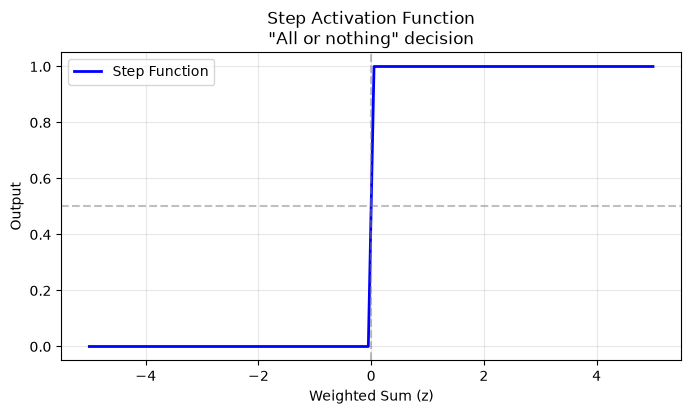

Step Function: Binary output (0 or 1)
  - Good for: Simple yes/no decisions
  - Problem: Can't learn gradually (no gradient)


In [4]:
def step_function(x, threshold=0):
    """Step activation: 1 if x > threshold, else 0"""
    return 1 if x > threshold else 0

# Visualize
x = np.linspace(-5, 5, 100)
y_step = [step_function(xi) for xi in x]

plt.figure(figsize=(8, 4))
plt.plot(x, y_step, 'b-', linewidth=2, label='Step Function')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Weighted Sum (z)')
plt.ylabel('Output')
plt.title('Step Activation Function\n"All or nothing" decision')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Step Function: Binary output (0 or 1)")
print("  - Good for: Simple yes/no decisions")
print("  - Problem: Can't learn gradually (no gradient)")

### 2. Sigmoid Function (What Logistic Regression Uses)

Remember Logistic Regression? It uses the **sigmoid** function to convert scores to probabilities.

```
SIGMOID FUNCTION:

Output │
   1   │                    ────────────
       │                ────
  0.5  │ - - - - - - -●- - - - - - - - -
       │          ────
   0   │──────────
       └─────────────┼─────────────────► Input (z)
                     0
                     
Formula: sigmoid(z) = 1 / (1 + e^(-z))

z = -5  →  sigmoid(-5) = 0.007  (almost 0)
z = 0   →  sigmoid(0)  = 0.5    (exactly middle)
z = 5   →  sigmoid(5)  = 0.993  (almost 1)
```

**WHY is this useful?**
- Output is always between 0 and 1 → perfect for probabilities!
- Smooth curve → can learn gradually (has gradient)
- Nice interpretation: "73% confident this is a cat"

**When to use:** Output layer for **binary classification** (yes/no, cat/dog, survived/died)

**The problem for DEEP networks:**
```
VANISHING GRADIENT PROBLEM:

When z is very large or very small, sigmoid is nearly flat:

       │                    ══════════  ← slope ≈ 0 here!
       │                ────
  0.5  │            ────
       │        ────
       │════════                        ← slope ≈ 0 here too!
       └────────────────────────────────►

When slope ≈ 0, learning stops!
Signal can't flow backward through many layers.
This is why deep networks struggled before ReLU.
```

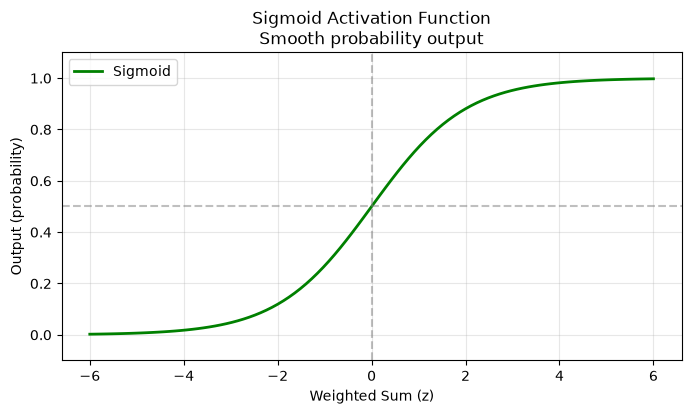

Sigmoid Function: Output between 0 and 1
  - Good for: Binary classification (probability)
  - Formula: 1 / (1 + e^(-z))
  - Problem: 'Vanishing gradient' in deep networks


In [5]:
def sigmoid(x):
    """Sigmoid activation: smooth curve from 0 to 1"""
    return 1 / (1 + np.exp(-x))

# Visualize
x = np.linspace(-6, 6, 100)
y_sigmoid = sigmoid(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y_sigmoid, 'g-', linewidth=2, label='Sigmoid')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Weighted Sum (z)')
plt.ylabel('Output (probability)')
plt.title('Sigmoid Activation Function\nSmooth probability output')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()

print("Sigmoid Function: Output between 0 and 1")
print("  - Good for: Binary classification (probability)")
print("  - Formula: 1 / (1 + e^(-z))")
print("  - Problem: 'Vanishing gradient' in deep networks")

### 3. ReLU (Rectified Linear Unit) - The Modern Standard

**ReLU revolutionized deep learning in 2012!** It's dead simple but incredibly effective.

```
ReLU FUNCTION:

Output │
       │                    /
       │                   /
       │                  /
       │                 /
   0   │────────────────●
       └─────────────────┼─────────────► Input (z)
                         0
                         
Formula: ReLU(z) = max(0, z)

If z < 0: output = 0
If z ≥ 0: output = z

Examples:
ReLU(-5) = 0
ReLU(0)  = 0
ReLU(3)  = 3
ReLU(100) = 100
```

---

### "Wait - ReLU Looks Linear! How Does It Break Linearity?"

Great observation! ReLU is indeed a straight line for positive values. So how does it make the network non-linear?

**The key: ReLU is PIECEWISE linear - it has a "kink" (a sharp corner/bend) at zero.**

```
WHAT IS A "KINK"?

    A kink is simply a sharp corner where a line suddenly changes direction.

    ✗ Smooth curve (no kink):     ✓ Kinked line (like ReLU):

         ╭───                         │
        ╱                             │
       ╱                         ─────●
      ╱                              (kink = the corner!)

    Think of folding a piece of paper - the fold creates a kink!

THE KINK IS THE KEY:

    Output │
           │                    /
           │                   /  ← Linear here (slope = 1)
           │                  /
           │                 /
           │────────────────●  ← THE KINK! (at z = 0)
           │ ↑
           │ Linear here too (slope = 0)
           └─────────────────────────────► Input (z)

    A truly linear function would be ONE straight line.
    ReLU is TWO different lines joined at a kink.
    This kink = non-linearity!
```

**But the REAL magic happens when you combine many neurons:**

```
ONE NEURON: Just one kink (not very expressive)

    ────────●/////////

MANY NEURONS: Many kinks at different positions!

    Neuron 1:  ────●////////
    Neuron 2:  ──────────●////
    Neuron 3:  ●////////////////
    
    Combined, they can approximate ANY curved shape:
    
         ●
        /        /   \        ← This curve is made of many small linear pieces!
      /          /       ●
    ●
```

**Concrete example:**

```
APPROXIMATING A CURVE WITH RELU NEURONS:

Imagine you want to learn a parabola (y = x²).
A single line can't do it. But multiple ReLU neurons can!

    y │
      │        ╱╲          ← True curve (parabola)
      │       ╱  ╲
      │      ╱    ╲
      │     ╱      ╲
      │────╱────────╲────
      └──────────────────► x

    ReLU approximation (with 4 neurons):
    
    y │
      │       /\           ← Piecewise linear approximation!
      │      /        │     /          │    /            │───/────────\─────
      └──────────────────► x
    
    Each "/" and "" segment comes from a different ReLU neuron.
    More neurons = more segments = better approximation!
```

**The mathematical insight:**
- One ReLU = one "fold" in the decision boundary
- Many ReLUs = many folds = can approximate any shape
- This is why neural networks are "universal approximators"

---

**WHY did ReLU change everything?**

1. **No vanishing gradient for positive values:**
   ```
   Sigmoid gradient shrinks to ~0 for large values
   ReLU gradient stays at 1 forever!
   
   This means deep networks can actually learn!
   ```

2. **Computationally simple:**
   ```
   Sigmoid: 1 / (1 + e^(-z))  ← requires exponent, division
   ReLU:    max(0, z)          ← just compare and pick!
   
   ReLU is ~6x faster to compute!
   ```

3. **Sparse activation:**
   ```
   With ReLU, ~50% of neurons output 0
   This means fewer neurons "fire" at once
   → Simpler, more efficient network
   ```

**When to use:** HIDDEN LAYERS in almost every modern network!

**The catch:** "Dead ReLU" problem
```
If a neuron's weights cause it to always output negative z,
it will ALWAYS output 0 and never recover (it's "dead").

Solution: Variants like Leaky ReLU, but standard ReLU usually works fine.
```

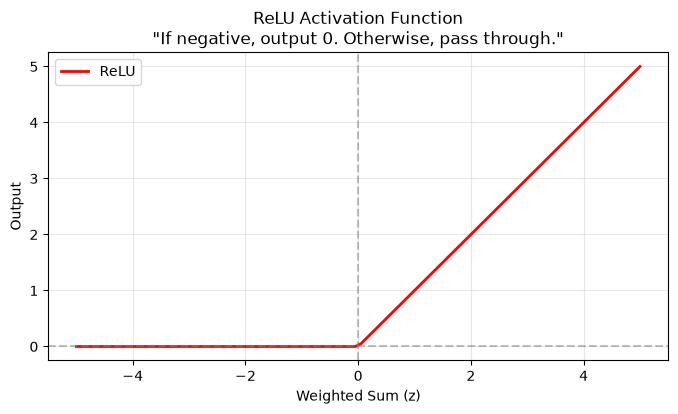

ReLU Function: max(0, x)
  - Good for: Hidden layers in deep networks
  - Why popular: Simple, fast, avoids vanishing gradient
  - Rule: Negative → 0, Positive → unchanged


In [6]:
def relu(x):
    """ReLU activation: max(0, x)"""
    return np.maximum(0, x)

# Visualize
x = np.linspace(-5, 5, 100)
y_relu = relu(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y_relu, 'r-', linewidth=2, label='ReLU')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Weighted Sum (z)')
plt.ylabel('Output')
plt.title('ReLU Activation Function\n"If negative, output 0. Otherwise, pass through."')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ReLU Function: max(0, x)")
print("  - Good for: Hidden layers in deep networks")
print("  - Why popular: Simple, fast, avoids vanishing gradient")
print("  - Rule: Negative → 0, Positive → unchanged")

### 4. Softmax - For Multi-class Classification

What if you have MORE than 2 classes? (e.g., digits 0-9, or cat/dog/bird/fish?)

Sigmoid gives you ONE probability. **Softmax gives you MULTIPLE probabilities that sum to 1.**

```
THE PROBLEM WITH SIGMOID FOR MULTI-CLASS:

You want to classify digits 0-9 (10 classes).
You could train 10 separate sigmoid outputs:

    P(digit=0) = 0.1
    P(digit=1) = 0.2
    P(digit=2) = 0.3
    ...
    P(digit=9) = 0.4
    ──────────────────
    SUM = 2.5   ← WRONG! Probabilities should sum to 1!

SOFTMAX SOLUTION:

Softmax converts raw scores to probabilities that SUM TO 1:

    Raw scores:        Softmax output:
    z0 = 2.0           P(0) = 0.14
    z1 = 1.0           P(1) = 0.05
    z2 = 0.1           P(2) = 0.02
    z3 = 3.5    →      P(3) = 0.64  ← highest!
    z4 = 0.2           P(4) = 0.02
    ...                ...
                       ────────────
                       SUM = 1.00 ✓
                       
    Prediction: Digit 3 (64% confident)
```

**Formula:**
```
softmax(zi) = e^zi / Σ(e^zj)

For each score, take e^score, then divide by sum of all e^scores.
```

**When to use:** OUTPUT LAYER for **multi-class classification** (>2 classes)

In [7]:
def softmax(x):
    """Softmax: converts scores to probabilities that sum to 1"""
    exp_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return exp_x / exp_x.sum()

# Example: raw scores from a network trying to classify digits 0-9
raw_scores = np.array([2.0, 1.0, 0.1, 3.5, 0.2, 0.3, 0.1, 0.05, 0.1, 0.2])

probabilities = softmax(raw_scores)

print("Raw scores from network:")
for i, score in enumerate(raw_scores):
    print(f"  Digit {i}: {score:.2f}")

print(f"\nAfter Softmax (probabilities):")
for i, prob in enumerate(probabilities):
    bar = '█' * int(prob * 50)
    print(f"  Digit {i}: {prob:.3f} {bar}")

print(f"\nSum of probabilities: {probabilities.sum():.4f}")
print(f"Predicted digit: {np.argmax(probabilities)} (highest probability)")

Raw scores from network:
  Digit 0: 2.00
  Digit 1: 1.00
  Digit 2: 0.10
  Digit 3: 3.50
  Digit 4: 0.20
  Digit 5: 0.30
  Digit 6: 0.10
  Digit 7: 0.05
  Digit 8: 0.10
  Digit 9: 0.20

After Softmax (probabilities):
  Digit 0: 0.144 ███████
  Digit 1: 0.053 ██
  Digit 2: 0.022 █
  Digit 3: 0.644 ████████████████████████████████
  Digit 4: 0.024 █
  Digit 5: 0.026 █
  Digit 6: 0.022 █
  Digit 7: 0.020 █
  Digit 8: 0.022 █
  Digit 9: 0.024 █

Sum of probabilities: 1.0000
Predicted digit: 3 (highest probability)


### Summary: Which Activation When?

| Activation | Formula | Output Range | Use For |
|------------|---------|--------------|----------|
| Step | 0 or 1 | {0, 1} | Simple perceptrons (historical) |
| Sigmoid | 1/(1+e^-x) | (0, 1) | Binary classification output |
| ReLU | max(0, x) | [0, ∞) | Hidden layers (most common!) |
| Softmax | e^xi / Σe^xj | (0, 1), sum=1 | Multi-class output |

---

## Hands-On: Building a Perceptron Decision System

We've covered a lot of theory - weighted sums, bias, activation functions. Now let's put it all together and **build a working perceptron from scratch!**

This will make everything concrete. We'll use a simple real-world example:

**The Decision:** Should you go outside today?

**Inputs:**
- Temperature (°F)
- Is it raining? (1 = Yes, 0 = No)

**What the perceptron will do:**
1. Take temperature and rain as inputs
2. Multiply by weights (how much each factor matters)
3. Add bias (baseline preference)
4. Apply step activation (yes/no decision)

**Weights and settings (these match Exercise 2 in your homework!):**
- Temperature weight = 0.6 (warmer = more likely to go out)
- Rain weight = 0.4 (rain is only ever 0 or 1, so it adds at most 0.4 points - a whisper next to temperature's tens of points)
- Bias = 2
- Decision threshold: Go outside if weighted_sum > 20

In [8]:
def perceptron_go_outside(temperature: float, is_raining: int) -> tuple[int, float]:
    """
    Simple perceptron to decide if you should go outside.

    Parameters:
        temperature: Temperature in Fahrenheit
        is_raining: 1 if raining, 0 if not

    Returns:
        (decision, weighted_sum): 1=go outside, 0=stay inside
    """
    # Weights and bias (these match your exercises!)
    w_temp = 0.6
    w_rain = 0.4
    bias = 2
    threshold = 20  # Decision threshold

    # Step 1: Calculate weighted sum
    weighted_sum = (temperature * w_temp) + (is_raining * w_rain) + bias

    # Step 2: Apply step activation
    decision = 1 if weighted_sum > threshold else 0

    return decision, weighted_sum

# Test cases
print("PERCEPTRON: Should I go outside?")
print("=" * 60)
print(f"Formula: weighted_sum = (temp × 0.6) + (rain × 0.4) + 2")
print(f"Decision: Go outside if weighted_sum > 20")
print("=" * 60)

test_cases = [
    (70, 0, "Case 1: 70°F, No rain"),
    (50, 1, "Case 2: 50°F, Raining"),
    (30, 0, "Case 3: 30°F, No rain"),
    (35, 1, "Case 4: 35°F, Raining"),
]

for temp, rain, description in test_cases:
    decision, weighted_sum = perceptron_go_outside(temp, rain)
    result = "Go outside!" if decision == 1 else "Stay inside"
    rain_str = "Yes" if rain else "No"
    print(f"\n{description}:")
    print(f"  Weighted sum: ({temp} × 0.6) + ({rain} × 0.4) + 2 = {weighted_sum}")
    print(f"  {weighted_sum} {'>' if decision else '≤'} 20 → {result}")

PERCEPTRON: Should I go outside?
Formula: weighted_sum = (temp × 0.6) + (rain × 0.4) + 2
Decision: Go outside if weighted_sum > 20

Case 1: 70°F, No rain:
  Weighted sum: (70 × 0.6) + (0 × 0.4) + 2 = 44.0
  44.0 > 20 → Go outside!

Case 2: 50°F, Raining:
  Weighted sum: (50 × 0.6) + (1 × 0.4) + 2 = 32.4
  32.4 > 20 → Go outside!

Case 3: 30°F, No rain:
  Weighted sum: (30 × 0.6) + (0 × 0.4) + 2 = 20.0
  20.0 ≤ 20 → Stay inside

Case 4: 35°F, Raining:
  Weighted sum: (35 × 0.6) + (1 × 0.4) + 2 = 23.4
  23.4 > 20 → Go outside!


### Exercise: Verify the Perceptron (Matches Exercise 2 in your homework!)

Using the formula: `weighted_sum = (temp × 0.6) + (rain × 0.4) + 2`

**Calculate by hand:**
1. Case 1: Temperature = 70°F, Rain = 0 (No)
2. Case 2: Temperature = 50°F, Rain = 1 (Yes)

**Then answer:** Did the perceptron suggest going outside in both cases? Why or why not?

In [9]:
# Your calculations here:
# Case 1: (70 × 0.6) + (0 × 0.4) + 2 = 44 > 20
# Case 2: (50 × 0.6) + (1 × 0.4) + 2 = 32.4 > 20
decision, weighted_sum = perceptron_go_outside(70, 0)
result = "Go outside!" if decision == 1 else "Stay inside"
rain_str = "Yes" if rain else "No"
print(f"\n{description}:")
print(f"  Weighted sum: ({temp} × 0.6) + ({rain} × 0.4) + 2 = {weighted_sum}")
print(f"  {weighted_sum} {'>' if decision else '≤'} 20 → {result}")



Case 4: 35°F, Raining:
  Weighted sum: (35 × 0.6) + (1 × 0.4) + 2 = 44.0
  44.0 > 20 → Go outside!


In [10]:
# Solution
print("Case 1: Temperature = 70°F, Rain = 0")
print("  weighted_sum = (70 × 0.6) + (0 × 0.4) + 2")
print("  weighted_sum = 42 + 0 + 2 = 44")
print("  44 > 20 → Go outside!")

print("\nCase 2: Temperature = 50°F, Rain = 1")
print("  weighted_sum = (50 × 0.6) + (1 × 0.4) + 2")
print("  weighted_sum = 30 + 0.4 + 2 = 32.4")
print("  32.4 > 20 → Go outside!")

print("\n" + "=" * 50)
print("INTERPRETATION:")
print("  Both cases suggest going outside!")
print("  Why? The temperature contribution dominates.")
print("  Even 50°F gives 30 points, already above threshold of 20.")
print("  Rain only adds 0.4 - barely affects the decision.")
print("\n  This shows weights matter! If rain should prevent")
print("  going outside, it needs a NEGATIVE weight or higher magnitude.")

Case 1: Temperature = 70°F, Rain = 0
  weighted_sum = (70 × 0.6) + (0 × 0.4) + 2
  weighted_sum = 42 + 0 + 2 = 44
  44 > 20 → Go outside!

Case 2: Temperature = 50°F, Rain = 1
  weighted_sum = (50 × 0.6) + (1 × 0.4) + 2
  weighted_sum = 30 + 0.4 + 2 = 32.4
  32.4 > 20 → Go outside!

INTERPRETATION:
  Both cases suggest going outside!
  Why? The temperature contribution dominates.
  Even 50°F gives 30 points, already above threshold of 20.
  Rain only adds 0.4 - barely affects the decision.

  This shows weights matter! If rain should prevent
  going outside, it needs a NEGATIVE weight or higher magnitude.


---

# Part 3: From Single Perceptron to Neural Networks

In the previous section, you built a perceptron that makes "go outside" decisions. It worked! But notice something: the perceptron drew a **single line** through the decision space - temperatures above a certain threshold led to "go outside."

**What if the real world is more complicated?**

What if the decision can't be captured by a single line? This brings us to the fundamental limitation of perceptrons - and why we need to stack them into **neural networks**.

---

## The Problem: One Perceptron Can Only Draw Straight Lines

Remember from ML: Logistic Regression draws a **linear boundary** (straight line in 2D, flat plane in higher dimensions).

A single perceptron has the SAME limitation!

```
PROBLEMS A SINGLE PERCEPTRON CAN SOLVE:

    Linearly Separable (CAN draw a line between classes):

    Class 0          Class 1
    ○ ○ ○    │    ● ● ●
    ○ ○      │      ● ●
      ○      │        ●
             │
         One line separates them perfectly!


PROBLEMS A SINGLE PERCEPTRON CANNOT SOLVE:

    NOT Linearly Separable (NO single line can separate):

              ●
         ●    ○    ●
              ○ ○
         ●    ○    ●
              ●

    The circles are surrounded! No straight line works!
```

This limitation was discovered in 1969 and almost killed neural network research!

---

## "Wait - Can't SVM Handle This?"

You might be thinking: "We learned that **SVM with the kernel trick** can separate non-linear data. Why not just use that?"

**Great question!** You're absolutely right - SVM with a kernel (like RBF) CAN solve XOR and similar non-linear problems. So why do we need neural networks?

```
SVM WITH KERNEL vs NEURAL NETWORKS:

┌─────────────────────────────────────┬─────────────────────────────────────┐
│         SVM + Kernel Trick          │         Neural Networks             │
├─────────────────────────────────────┼─────────────────────────────────────┤
│ ✓ Works great for XOR               │ ✓ Works great for XOR               │
│ ✓ Strong theory (optimal margin)    │ ✓ Learns hierarchical features      │
│ ✓ Good for small/medium data        │ ✓ Scales to HUGE datasets           │
│                                     │                                     │
│ ✗ YOU choose the kernel (RBF, poly) │ ✓ Network LEARNS the transformation │
│ ✗ Doesn't scale well to millions    │ ✓ Handles millions of examples      │
│ ✗ Can't learn from raw pixels       │ ✓ Learns directly from raw data     │
│ ✗ No hierarchical features          │ ✓ Learns edges → shapes → objects   │
└─────────────────────────────────────┴─────────────────────────────────────┘
```

**The key differences:**

1. **Feature Learning**: With SVM, you pick a kernel and hope it's right. Neural networks LEARN the best transformation automatically.

2. **Scale**: SVM slows down dramatically with large datasets. Neural networks thrive on big data.

3. **Raw Data**: SVM needs good features. Neural networks can learn from raw pixels, audio waves, or text.

```
EXAMPLE: Image Classification

SVM approach:
    Raw pixels → [YOU design features] → SVM → Cat/Dog
                      ↑
              What features? Edge histograms?
              Color distributions? This is HARD!

Neural Network approach:
    Raw pixels → [Network learns features automatically] → Cat/Dog
                      ↑
              Layer 1 learns edges
              Layer 2 learns shapes
              Layer 3 learns object parts
              No manual design needed!
```

**Bottom line:** For tabular data with <100K samples, SVM might be just as good (or better!). But for images, text, audio, or massive datasets - neural networks are the way to go.

---

## The Famous XOR Problem

Now let's see a concrete example of what "not linearly separable" means.

The **XOR (Exclusive OR)** problem is the simplest possible example of a problem that CANNOT be solved by a single perceptron (or linear SVM without kernel). It became famous because it proved the limitation mathematically.

```
WHY XOR?

XOR is the SIMPLEST non-linearly-separable problem:
- Only 2 inputs (A and B)
- Only 4 possible input combinations
- Yet NO single line can solve it!

If a perceptron fails on something THIS simple,
imagine how it would fail on complex real-world problems!
```

**XOR (Exclusive OR)** is a simple logical operation:

```
XOR TRUTH TABLE:

    Input A    Input B    Output (A XOR B)
    ───────    ───────    ────────────────
       0          0              0
       0          1              1          ← different inputs = 1
       1          0              1          ← different inputs = 1
       1          1              0

"Output is 1 if inputs are DIFFERENT, 0 if inputs are SAME"
```

Now let's plot these 4 points and try to separate them with ONE line:

```
XOR PLOTTED ON A GRAPH:
                    
    B (Input 2)             
    │   
  1 │   ●(0,1)              ○(1,1)
    │      Output=1           Output=0
    │
    │
  0 │   ○(0,0)              ●(1,0)
    │      Output=0           Output=1
    └───────────────────────────────── A (Input 1)
        0                   1

    ● = Output is 1 (class 1)
    ○ = Output is 0 (class 0)

NOTICE: The ● points are at OPPOSITE corners!
        The ○ points are at OPPOSITE corners!
```

**Now try to draw ONE straight line that separates all ● from all ○:**

```
    Try 1 (horizontal):     Try 2 (vertical):     Try 3 (diagonal):
    
    │   ●       ○           │   ●   │   ○         │   ●       ○
    │   ─────────           │       │             │       \
    │   ○       ●           │   ○   │   ●         │   ○     \ ●
    
    FAILS!                  FAILS!                FAILS!
    ● and ○ on same side    ● and ○ on same side  Still can't separate!
```

**No matter how you rotate or position a single line, you CANNOT separate the classes!**

This is the mathematical proof that single perceptrons (and linear classifiers) have fundamental limitations.

**The solution?** Use MULTIPLE perceptrons (multiple lines) combined together. This is exactly what **hidden layers** do - and it's what makes neural networks so powerful!

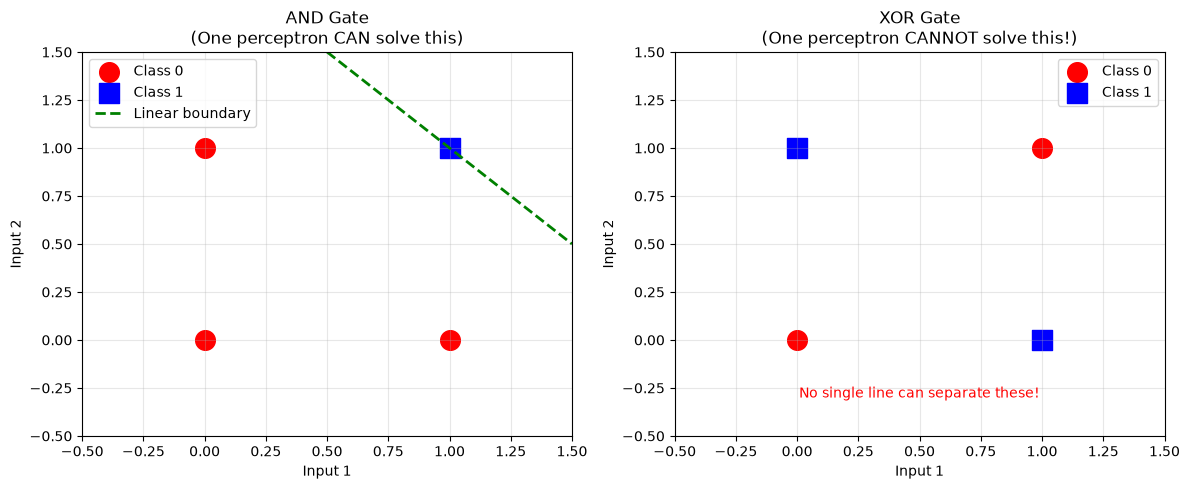

The XOR problem proved that single perceptrons have limits.
Solution: Stack multiple perceptrons into LAYERS!


In [11]:
# XOR Problem - impossible for a single perceptron!
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear problem (AND gate) - solvable by perceptron
ax1 = axes[0]
ax1.scatter([0, 0, 1], [0, 1, 0], c='red', s=200, label='Class 0', marker='o')
ax1.scatter([1], [1], c='blue', s=200, label='Class 1', marker='s')
ax1.plot([0.5, 1.5], [1.5, 0.5], 'g--', linewidth=2, label='Linear boundary')
ax1.set_xlim(-0.5, 1.5)
ax1.set_ylim(-0.5, 1.5)
ax1.set_xlabel('Input 1')
ax1.set_ylabel('Input 2')
ax1.set_title('AND Gate\n(One perceptron CAN solve this)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# XOR problem - NOT solvable by single perceptron
ax2 = axes[1]
ax2.scatter([0, 1], [0, 1], c='red', s=200, label='Class 0', marker='o')
ax2.scatter([0, 1], [1, 0], c='blue', s=200, label='Class 1', marker='s')
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel('Input 1')
ax2.set_ylabel('Input 2')
ax2.set_title('XOR Gate\n(One perceptron CANNOT solve this!)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.text(0.5, -0.3, 'No single line can separate these!', ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.show()

print("The XOR problem proved that single perceptrons have limits.")
print("Solution: Stack multiple perceptrons into LAYERS!")

## The Solution: Hidden Layers

**Key insight:** A single perceptron draws ONE line. But what if we combine MULTIPLE perceptrons?

```
TWO LINES CAN SOLVE XOR!

    B              
    │   ●(0,1)    \        ○(1,1)
    │              \
    │               \   Line 2
    │    Line 1      \
    │         \       
    │   ○(0,0) \      ●(1,0)
    │           \
    └─────────────────────────────── A

Line 1: Separates (0,0) and (1,1) from the others
Line 2: Separates (0,1) and (1,0) from the others

TOGETHER: They create TWO regions that isolate each class!
```

**This is exactly what a hidden layer does!**

```
NEURAL NETWORK FOR XOR:

INPUT LAYER          HIDDEN LAYER              OUTPUT LAYER
(2 inputs)           (2 neurons)               (1 output)

                     ┌─────────┐
    A ──────────────►│Neuron 1 │──────┐
         \     \     │ Line 1  │      │      ┌─────────┐
          \     \    └─────────┘      └─────►│         │
           \     \                           │ Output  │──► 0 or 1
            \     \  ┌─────────┐      ┌─────►│ Neuron  │
             \     ─►│Neuron 2 │──────┘      └─────────┘
    B ─────────────►│ Line 2  │
                     └─────────┘

Each hidden neuron learns ONE linear boundary.
The output neuron COMBINES them into a non-linear boundary!
```

---

## Why Do Hidden Layers Work?

**The magic:** Hidden layers learn INTERMEDIATE FEATURES (representations).

```
EXAMPLE: Recognizing the digit "8"

RAW PIXELS              HIDDEN LAYER 1         HIDDEN LAYER 2         OUTPUT
(784 inputs)            (learns edges)         (learns shapes)        (10 classes)

  ████████               │  ╱  ─  ╲              ○  □  △              0: 2%
  ██    ██               ←─┘                                          1: 1%
  ████████         →     Neuron 1: top curve     Neuron 1: top loop    2: 3%
  ██    ██               Neuron 2: bottom curve  Neuron 2: bottom loop 3: 1%
  ████████               Neuron 3: vertical edge ...                   ...
                         ...                                           8: 87% ←
                                                                       9: 2%

Each layer builds on the previous one:
- Layer 1: pixels → edges
- Layer 2: edges → shapes  
- Output: shapes → digit classification
```

**"Deep" learning = Many hidden layers**
- 2-3 layers: simple patterns
- 10-100+ layers: complex patterns (state of the art)
- GPT-4 has 120+ layers!

---

## Neural Network Architecture Terminology

```
ANATOMY OF A NEURAL NETWORK:

┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│   INPUT LAYER      HIDDEN LAYERS           OUTPUT LAYER         │
│   (features)       (learned features)      (predictions)        │
│                                                                 │
│       ○               ○      ○                  ○                │
│       ○ ──────────►  ○      ○  ──────────►    ○                │
│       ○               ○      ○                  ○                │
│       ○                                                         │
│                                                                 │
│    (4 inputs)      (5 neurons) (4 neurons)   (3 outputs)        │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘

TERMINOLOGY:
- Fully connected (dense): Every neuron connects to every neuron in next layer
- Width: Number of neurons in a layer
- Depth: Number of layers (more layers = "deeper")
- Parameters: All the weights + biases (what the network learns)
```

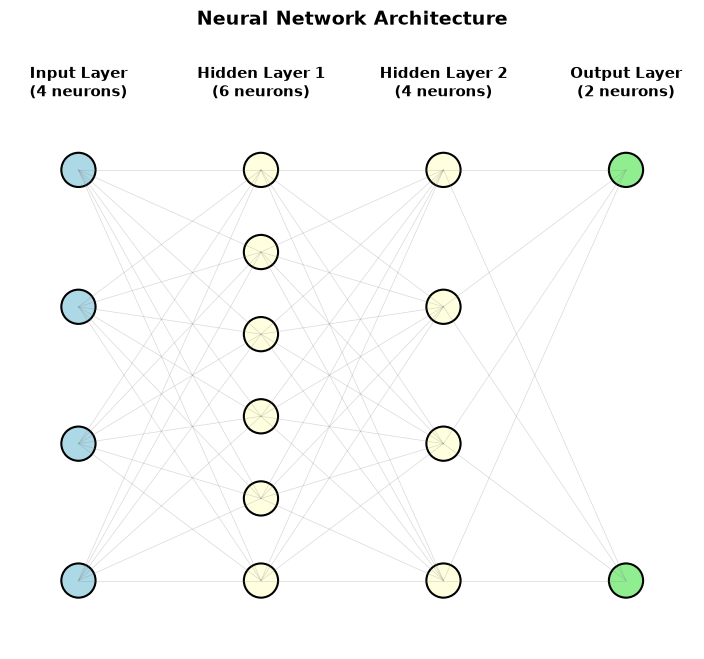

This network has:
  - 4 input features
  - 2 hidden layers (6 and 4 neurons)
  - 2 output classes

'Deep' learning typically means 2+ hidden layers


In [12]:
# Visualize a neural network architecture
def draw_neural_network(layer_sizes, layer_names):
    """Draw a neural network diagram"""
    fig, ax = plt.subplots(figsize=(12, 8))

    n_layers = len(layer_sizes)
    max_neurons = max(layer_sizes)

    # Calculate positions
    layer_positions = np.linspace(1, 9, n_layers)

    neuron_positions = []
    for layer_idx, n_neurons in enumerate(layer_sizes):
        y_positions = np.linspace(1, 7, n_neurons) if n_neurons > 1 else [4]
        neuron_positions.append(y_positions)

    # Draw connections
    for layer_idx in range(n_layers - 1):
        for y1 in neuron_positions[layer_idx]:
            for y2 in neuron_positions[layer_idx + 1]:
                ax.plot([layer_positions[layer_idx], layer_positions[layer_idx + 1]],
                       [y1, y2], 'gray', alpha=0.3, linewidth=0.5)

    # Draw neurons
    colors = ['lightblue', 'lightyellow', 'lightyellow', 'lightgreen']
    for layer_idx, (x, ys) in enumerate(zip(layer_positions, neuron_positions)):
        for y in ys:
            circle = plt.Circle((x, y), 0.25, color=colors[min(layer_idx, len(colors)-1)],
                               ec='black', linewidth=1.5)
            ax.add_patch(circle)

    # Add labels
    for layer_idx, (x, name) in enumerate(zip(layer_positions, layer_names)):
        ax.text(x, 8, f'{name}\n({layer_sizes[layer_idx]} neurons)',
               ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Neural Network Architecture', fontsize=14, fontweight='bold')

    return fig, ax

# Draw a simple network
layer_sizes = [4, 6, 4, 2]
layer_names = ['Input Layer', 'Hidden Layer 1', 'Hidden Layer 2', 'Output Layer']
draw_neural_network(layer_sizes, layer_names)
plt.show()

print("This network has:")
print("  - 4 input features")
print("  - 2 hidden layers (6 and 4 neurons)")
print("  - 2 output classes")
print("\n'Deep' learning typically means 2+ hidden layers")

---

# Part 4: Forward Propagation - How Data Flows Through a Network

**Let's recap where we are:**

| Part | What We Learned |
|------|-----------------|
| Part 1 | Deep Learning = neural networks that learn features automatically |
| Part 2 | A perceptron does: weighted sum → bias → activation |
| Part 3 | Stack perceptrons into layers to solve complex problems (like XOR) |
| **Part 4** | **How does data actually flow through these layers?** |

We know the architecture (input → hidden → output). We know each neuron does weighted sum + activation. But how do all these pieces work together to make a prediction?

This process is called **forward propagation** - and it's simpler than you might think!

---

## What is Forward Propagation?

**Forward propagation** = passing input data through the network, layer by layer, to get an output.

```
WHY IS IT CALLED "FORWARD"?

Data flows in ONE direction: Left to Right (Input → Output)

    INPUT         HIDDEN         OUTPUT
      ↓             ↓              ↓
    [x1]  ───►   [h1]   ───►    [y]
    [x2]  ───►   [h2]   ───►
    
    ──────────────────────────────────►
              FORWARD direction
              
Later, we'll learn "BACKWARD" propagation for training!
(gradients flow backward: Output → Input)
```

## The Forward Propagation Algorithm

Here's the key insight: **forward propagation is just repeating what a single perceptron does, for every neuron in every layer.**

For EACH layer in the network, we do two steps:

```
STEP 1: LINEAR TRANSFORMATION (Weighted Sum + Bias)
────────────────────────────────────────────────────
    z = W × x + b
    
    Where:
    - x = inputs to this layer (either raw data or previous layer's output)
    - W = weight matrix (learned)
    - b = bias vector (learned)
    - z = pre-activation value (before activation function)

STEP 2: NON-LINEAR ACTIVATION
────────────────────────────────────────────────────
    a = activation(z)
    
    Where:
    - z = pre-activation from step 1
    - activation = ReLU, Sigmoid, Softmax, etc.
    - a = activated output (becomes input to next layer)


REPEAT for each layer until you reach the output!
```

## Detailed Example: Single Layer Forward Pass

Let's trace through a simple example with actual numbers:

```
EXAMPLE: House Price Prediction (1 layer)

INPUTS:
    x1 = 2000  (square footage)
    x2 = 3     (number of bedrooms)

WEIGHTS (learned from training data):
    w1 = 0.5   (price per sq ft contribution)
    w2 = 0.7   (price per bedroom contribution)
    bias = 50000 (base price)

STEP 1: WEIGHTED SUM
    z = (x1 × w1) + (x2 × w2) + bias
    z = (2000 × 0.5) + (3 × 0.7) + 50000
    z = 1000 + 2.1 + 50000
    z = 51002.1

STEP 2: ACTIVATION (ReLU for this example)
    output = max(0, z)
    output = max(0, 51002.1)
    output = 51002.1

PREDICTION: $51,002.10
```

**Visual representation:**

```
                    w1 = 0.5
    x1 = 2000  ─────────────┐
                            │
                            ▼
                       ┌─────────┐     ┌──────────┐
                       │ Weighted│     │   ReLU   │
                       │   Sum   │────►│max(0, z) │────► $51,002
                       │ + bias  │     │          │
                       └─────────┘     └──────────┘
                            ▲
                            │
    x2 = 3     ─────────────┘
                    w2 = 0.7
```

In [13]:
# Let's implement forward propagation step by step with detailed output

print("=" * 70)
print("FORWARD PROPAGATION: Single Layer Example")
print("=" * 70)

# INPUTS - the raw data we want to make a prediction on
print("\n📊 INPUTS (what we're trying to predict from):")
x1 = 2000  # Square footage
x2 = 3     # Number of bedrooms
print(f"    x1 (Square Footage)    = {x1}")
print(f"    x2 (Number of Bedrooms) = {x2}")

# WEIGHTS - learned from training data (in practice, these are randomly
# initialized and then adjusted during training)
print("\n⚖️ WEIGHTS (learned during training):")
w1 = 0.5      # Weight for square footage
w2 = 0.7      # Weight for bedrooms
bias = 50000  # Base price

print(f"    w1 (weight for sq ft)   = {w1}")
print(f"    w2 (weight for bedrooms) = {w2}")
print(f"    bias (base price)       = ${bias:,}")

# STEP 1: LINEAR TRANSFORMATION (Weighted Sum + Bias)
print("\n" + "-" * 70)
print("STEP 1: LINEAR TRANSFORMATION (Weighted Sum + Bias)")
print("-" * 70)
print("\n    Formula: z = (x1 × w1) + (x2 × w2) + bias")
print(f"\n    Substituting values:")
print(f"    z = ({x1} × {w1}) + ({x2} × {w2}) + {bias}")
print(f"    z = {x1 * w1} + {x2 * w2} + {bias}")

z = (x1 * w1) + (x2 * w2) + bias
print(f"    z = {z}")

# STEP 2: ACTIVATION FUNCTION (ReLU)
print("\n" + "-" * 70)
print("STEP 2: ACTIVATION FUNCTION (ReLU)")
print("-" * 70)
print("\n    Formula: output = max(0, z)")
print(f"\n    Is z > 0? {z} > 0? {'Yes!' if z > 0 else 'No'}")

output = max(0, z)
print(f"    output = max(0, {z}) = {output}")

# FINAL RESULT
print("\n" + "=" * 70)
print(f"🏠 PREDICTED HOUSE PRICE: ${output:,.2f}")
print("=" * 70)

print("\n💡 KEY INSIGHT:")
print("    Each step is simple math - multiply, add, compare!")
print("    The 'magic' comes from learning the RIGHT weights during training.")

FORWARD PROPAGATION: Single Layer Example

📊 INPUTS (what we're trying to predict from):
    x1 (Square Footage)    = 2000
    x2 (Number of Bedrooms) = 3

⚖️ WEIGHTS (learned during training):
    w1 (weight for sq ft)   = 0.5
    w2 (weight for bedrooms) = 0.7
    bias (base price)       = $50,000

----------------------------------------------------------------------
STEP 1: LINEAR TRANSFORMATION (Weighted Sum + Bias)
----------------------------------------------------------------------

    Formula: z = (x1 × w1) + (x2 × w2) + bias

    Substituting values:
    z = (2000 × 0.5) + (3 × 0.7) + 50000
    z = 1000.0 + 2.0999999999999996 + 50000
    z = 51002.1

----------------------------------------------------------------------
STEP 2: ACTIVATION FUNCTION (ReLU)
----------------------------------------------------------------------

    Formula: output = max(0, z)

    Is z > 0? 51002.1 > 0? Yes!
    output = max(0, 51002.1) = 51002.1

🏠 PREDICTED HOUSE PRICE: $51,002.10

💡 KEY INS

## Practice: Forward Propagation by Hand (Exercise 4 Preview!)

This example uses the **exact same values** as Exercise 4 in your homework.

**The scenario:** Predict house price based on size and bedrooms.

```
GIVEN VALUES:

    Inputs:
        x1 = 2000  (Square Footage)
        x2 = 3     (Number of Bedrooms)
    
    Weights:
        w1 = 0.5   (contribution per square foot)
        w2 = 0.7   (contribution per bedroom)
        
    Bias:
        bias = 50,000  (base price)

YOUR TASK: Calculate the predicted price step by step!

STEP 1 - Calculate the weighted sum:
    z = (x1 × w1) + (x2 × w2) + bias
    z = (_____ × _____) + (_____ × _____) + _____
    z = _____ + _____ + _____
    z = _____

STEP 2 - Apply ReLU activation:
    output = max(0, z)
    output = max(0, _____)
    output = _____

FINAL ANSWER:
    Predicted House Price = $ _____
```

**Try calculating by hand BEFORE running the next cell!**

In [14]:
# Your calculation here:
# z = (2000 × 0.5) + (3 × 0.7) + 50000
# output = max(0, z) = ?



In [15]:
# SOLUTION - Forward Propagation (Exercise 4 Values)

print("=" * 70)
print("SOLUTION: Forward Propagation - House Price Prediction")
print("=" * 70)

# Given values (matching Exercise 4)
x1 = 2000    # Square Footage
x2 = 3       # Bedrooms
w1 = 0.5     # Weight for sq ft
w2 = 0.7     # Weight for bedrooms
bias = 50000 # Base price

print("\n📋 GIVEN:")
print(f"    x1 = {x1} (Square Footage)")
print(f"    x2 = {x2} (Number of Bedrooms)")
print(f"    w1 = {w1}")
print(f"    w2 = {w2}")
print(f"    bias = {bias:,}")

# STEP 1: Weighted Sum
print("\n" + "-" * 70)
print("STEP 1: WEIGHTED SUM")
print("-" * 70)
print("\n    Formula: z = (x1 × w1) + (x2 × w2) + bias")

term1 = x1 * w1
term2 = x2 * w2

print(f"\n    Breaking it down:")
print(f"    • Square footage contribution: {x1} × {w1} = {term1}")
print(f"    • Bedrooms contribution:       {x2} × {w2} = {term2}")
print(f"    • Base price (bias):           {bias}")

z = term1 + term2 + bias
print(f"\n    Adding them up:")
print(f"    z = {term1} + {term2} + {bias}")
print(f"    z = {z}")

# STEP 2: ReLU Activation
print("\n" + "-" * 70)
print("STEP 2: ReLU ACTIVATION")
print("-" * 70)
print("\n    Formula: output = max(0, z)")
print(f"\n    Since z = {z} is positive (> 0):")

output = max(0, z)
print(f"    output = max(0, {z})")
print(f"    output = {output}")

# Final Answer
print("\n" + "=" * 70)
print(f"✅ FINAL ANSWER: Predicted House Price = ${output:,.2f}")
print("=" * 70)

print("\n🎯 INTERPRETATION:")
print(f"    • A {x1} sq ft house with {x2} bedrooms is predicted to cost ${output:,.2f}")
print(f"    • The square footage contributed ${term1:,.0f} to the price")
print(f"    • Each bedroom added ${term2/x2:.2f} to the price")
print(f"    • The base price (regardless of size/rooms) is ${bias:,}")

SOLUTION: Forward Propagation - House Price Prediction

📋 GIVEN:
    x1 = 2000 (Square Footage)
    x2 = 3 (Number of Bedrooms)
    w1 = 0.5
    w2 = 0.7
    bias = 50,000

----------------------------------------------------------------------
STEP 1: WEIGHTED SUM
----------------------------------------------------------------------

    Formula: z = (x1 × w1) + (x2 × w2) + bias

    Breaking it down:
    • Square footage contribution: 2000 × 0.5 = 1000.0
    • Bedrooms contribution:       3 × 0.7 = 2.0999999999999996
    • Base price (bias):           50000

    Adding them up:
    z = 1000.0 + 2.0999999999999996 + 50000
    z = 51002.1

----------------------------------------------------------------------
STEP 2: ReLU ACTIVATION
----------------------------------------------------------------------

    Formula: output = max(0, z)

    Since z = 51002.1 is positive (> 0):
    output = max(0, 51002.1)
    output = 51002.1

✅ FINAL ANSWER: Predicted House Price = $51,002.10

🎯 INTERP

## Multi-Layer Forward Propagation (The Real Thing!)

In a real neural network, data flows through MULTIPLE layers. Each layer:
1. Receives input from the previous layer
2. Applies weights + bias (linear transformation)
3. Applies activation function
4. Passes output to the next layer

```
MULTI-LAYER FORWARD PROPAGATION:

LAYER 1 (Hidden):                      LAYER 2 (Output):

INPUT        WEIGHTED SUM    ACTIVATION    WEIGHTED SUM    ACTIVATION    OUTPUT
  │              │              │              │               │            │
  ▼              ▼              ▼              ▼               ▼            ▼
┌────┐      ┌────────┐     ┌────────┐     ┌────────┐      ┌────────┐   ┌────────┐
│ x  │─────►│z1=W1·x │────►│a1=ReLU │────►│z2=W2·a1│─────►│a2=Softmax│─►│ ŷ     │
│    │      │  + b1  │     │ (z1)   │     │  + b2  │      │  (z2)    │  │        │
└────┘      └────────┘     └────────┘     └────────┘      └────────┘   └────────┘

The KEY INSIGHT:
- Each layer's OUTPUT becomes the next layer's INPUT
- This is just the same operation repeated!
- That's why neural networks are "composable"
```

### Matrix Notation: How It Works at Scale

For efficiency, we use **matrix multiplication** to process many inputs at once:

```
SINGLE INPUT vs MATRIX NOTATION:

Single input (1 sample, 2 features):
    z = w1*x1 + w2*x2 + b        ← scalar math

Matrix notation (many samples at once):
    Z = X @ W + b                 ← matrix math
    
Where:
    X = input matrix     (samples × features)
    W = weight matrix    (features × neurons)
    b = bias vector      (1 × neurons, broadcasted)
    Z = output matrix    (samples × neurons)

WHY MATRICES?
- GPU can multiply millions of numbers at once
- Much faster than loops!
- Same math, different notation
```

Let's trace through a concrete 2-layer example:

In [16]:
# Multi-layer Forward Propagation with Detailed Step-by-Step

print("=" * 70)
print("MULTI-LAYER FORWARD PROPAGATION")
print("Network: 2 inputs → 3 hidden neurons → 1 output")
print("=" * 70)

# ═══════════════════════════════════════════════════════════════════════
# SETUP: Define our network architecture
# ═══════════════════════════════════════════════════════════════════════

# Input: 2 features (like [square_footage, bedrooms])
X = np.array([0.5, 0.8])
print(f"\n📊 INPUT (x):")
print(f"    Shape: {X.shape} (2 features)")
print(f"    Values: {X}")

# LAYER 1: 2 inputs → 3 hidden neurons
# Weight matrix: each row is an input, each column is a neuron
W1 = np.array([[0.2, 0.4, 0.1],    # weights from x1 to neurons 1,2,3
               [0.3, 0.1, 0.5]])   # weights from x2 to neurons 1,2,3
b1 = np.array([0.1, 0.2, 0.3])     # bias for each neuron

print(f"\n🔧 LAYER 1 (Hidden Layer):")
print(f"    W1 shape: {W1.shape} (2 inputs × 3 neurons)")
print(f"    b1 shape: {b1.shape} (3 biases)")
print(f"    Activation: ReLU")

# LAYER 2: 3 hidden → 1 output
W2 = np.array([[0.5],    # weight from hidden neuron 1
               [0.3],    # weight from hidden neuron 2
               [0.4]])   # weight from hidden neuron 3
b2 = np.array([0.1])

print(f"\n🔧 LAYER 2 (Output Layer):")
print(f"    W2 shape: {W2.shape} (3 hidden × 1 output)")
print(f"    b2 shape: {b2.shape} (1 bias)")
print(f"    Activation: Sigmoid")

# ═══════════════════════════════════════════════════════════════════════
# FORWARD PASS: Push data through the network
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print("FORWARD PASS - LAYER 1 (Hidden)")
print("=" * 70)

# Step 1a: Linear transformation (weighted sum + bias)
print("\n    Step 1a: Linear Transformation")
print(f"    z1 = X @ W1 + b1")
print(f"\n    Matrix multiplication:")
print(f"    [x1, x2] @ [[w11, w12, w13],    +  [b1, b2, b3]")
print(f"                [w21, w22, w23]]")
print(f"\n    [{X[0]}, {X[1]}] @ [[{W1[0,0]}, {W1[0,1]}, {W1[0,2]}],  +  [{b1[0]}, {b1[1]}, {b1[2]}]")
print(f"                  [{W1[1,0]}, {W1[1,1]}, {W1[1,2]}]]")

z1 = np.dot(X, W1) + b1
print(f"\n    z1 = {z1}")

# Step 1b: Activation (ReLU)
print("\n    Step 1b: ReLU Activation")
print(f"    a1 = max(0, z1) for each element")

a1 = np.maximum(0, z1)  # ReLU
print(f"    a1 = {a1}")
print(f"\n    (All values positive, so no change from ReLU)")

print("\n" + "=" * 70)
print("FORWARD PASS - LAYER 2 (Output)")
print("=" * 70)

# Step 2a: Linear transformation
print("\n    Step 2a: Linear Transformation")
print(f"    z2 = a1 @ W2 + b2")
print(f"\n    The hidden layer output a1 becomes the input!")
print(f"    [{a1[0]:.2f}, {a1[1]:.2f}, {a1[2]:.2f}] @ [[{W2[0,0]}],  +  [{b2[0]}]")
print(f"                            [{W2[1,0]}],")
print(f"                            [{W2[2,0]}]]")

z2 = np.dot(a1, W2) + b2
print(f"\n    z2 = {z2}")

# Step 2b: Activation (Sigmoid for output)
print("\n    Step 2b: Sigmoid Activation")
print(f"    a2 = 1 / (1 + e^(-z2))")

a2 = sigmoid(z2)
print(f"    a2 = {a2}")

# ═══════════════════════════════════════════════════════════════════════
# RESULT
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 70)
print(f"✅ FINAL OUTPUT: {a2[0]:.4f}")
print("=" * 70)
print(f"\n🎯 INTERPRETATION:")
print(f"    • For input [{X[0]}, {X[1]}], the network outputs {a2[0]:.4f}")
print(f"    • Since we used sigmoid, this is a probability: {a2[0]*100:.1f}%")
print(f"    • In binary classification: {'Class 1' if a2[0] > 0.5 else 'Class 0'}")

MULTI-LAYER FORWARD PROPAGATION
Network: 2 inputs → 3 hidden neurons → 1 output

📊 INPUT (x):
    Shape: (2,) (2 features)
    Values: [0.5 0.8]

🔧 LAYER 1 (Hidden Layer):
    W1 shape: (2, 3) (2 inputs × 3 neurons)
    b1 shape: (3,) (3 biases)
    Activation: ReLU

🔧 LAYER 2 (Output Layer):
    W2 shape: (3, 1) (3 hidden × 1 output)
    b2 shape: (1,) (1 bias)
    Activation: Sigmoid

FORWARD PASS - LAYER 1 (Hidden)

    Step 1a: Linear Transformation
    z1 = X @ W1 + b1

    Matrix multiplication:
    [x1, x2] @ [[w11, w12, w13],    +  [b1, b2, b3]
                [w21, w22, w23]]

    [0.5, 0.8] @ [[0.2, 0.4, 0.1],  +  [0.1, 0.2, 0.3]
                  [0.3, 0.1, 0.5]]

    z1 = [0.44 0.48 0.75]

    Step 1b: ReLU Activation
    a1 = max(0, z1) for each element
    a1 = [0.44 0.48 0.75]

    (All values positive, so no change from ReLU)

FORWARD PASS - LAYER 2 (Output)

    Step 2a: Linear Transformation
    z2 = a1 @ W2 + b2

    The hidden layer output a1 becomes the input!
    

---

# Part 5: How Neural Networks Learn (Training)

**Let's recap our journey so far:**

| Part | What We Covered |
|------|-----------------|
| Part 1 | Why deep learning? (automatic feature learning) |
| Part 2 | The perceptron: weighted sum + bias + activation |
| Part 3 | Stack into layers → solve non-linear problems |
| Part 4 | Forward propagation: input → layers → prediction |
| **Part 5** | **But where do the weights come from?** |

In Part 4, we used weights like `w1 = 0.5` and `bias = 50000` to make predictions. But we never explained **how the network figures out these values!**

Think about it:
- We said weights are "learned from data"
- But what does that actually mean?
- How does a network know that `w1 = 0.5` is good and `w1 = 0.3` is bad?

**This is what training is all about: finding the best weights.**

---

## The Big Picture: Learning = Minimizing Mistakes

The goal of training is beautifully simple: **find weights that make the smallest prediction errors.**

```
THE TRAINING LOOP (what happens thousands of times):

┌──────────────────────────────────────────────────────────────┐
│  1. FORWARD PASS: Make a prediction with current weights     │
│         Input: [2000 sq ft, 3 bedrooms]                      │
│         Prediction: $42,000  (with random initial weights)   │
│                                                              │
│  2. MEASURE ERROR: How wrong were we?                        │
│         Actual price: $250,000                               │
│         Error: |$250,000 - $42,000| = $208,000  (very wrong!)│
│                                                              │
│  3. BACKWARD PASS: Which weights caused the error?           │
│         "w1 should be bigger, bias should be bigger..."      │
│                                                              │
│  4. UPDATE WEIGHTS: Adjust to reduce error                   │
│         w1: 0.1 → 0.15                                       │
│         bias: 1000 → 5000                                    │
│                                                              │
│  5. REPEAT from step 1 with new weights                      │
└──────────────────────────────────────────────────────────────┘

After thousands of iterations:
    Weights converge to good values!
    Predictions become accurate!
```

Let's explore each component of this process:

---

## Loss Functions: Measuring "How Wrong"

A **loss function** (also called cost function) quantifies how wrong our predictions are.

```
WHY DO WE NEED A LOSS FUNCTION?

Without a number, we can't improve systematically!
"The prediction was bad" → How bad? In which direction?

With a loss function:
"Loss = 15000" → We can try to make this number smaller!
"Loss went from 15000 to 12000" → We're improving!
```

### Loss Function for Regression: Mean Squared Error (MSE)

When predicting continuous values (like house prices):

```
MEAN SQUARED ERROR (MSE):

    MSE = (1/n) × Σ(prediction - actual)²

    Example with 3 houses:
    
    House    Predicted    Actual    Error    Error²
    ─────    ─────────    ──────    ─────    ──────
      1      $200,000    $220,000  -$20,000  400,000,000
      2      $350,000    $340,000  +$10,000  100,000,000
      3      $150,000    $180,000  -$30,000  900,000,000
                                            ───────────────
    MSE = (400M + 100M + 900M) / 3 = 466,666,667

    WHY SQUARED?
    1. Makes all errors positive (can't cancel out)
    2. Penalizes big errors more than small ones
       - $10,000 off → 100M penalty
       - $30,000 off → 900M penalty (9x more!)
```

### Loss Function for Classification: Cross-Entropy

When predicting categories (like digits 0-9):

```
CROSS-ENTROPY LOSS:

For binary classification (yes/no):
    Loss = -[y × log(p) + (1-y) × log(1-p)]
    
For multi-class (digits 0-9):
    Loss = -Σ yi × log(pi)  (for each class i)

INTUITION:
    If true class is "3" and we predict:
    - P(3) = 0.9  → Loss = -log(0.9) = 0.105  (small loss, good!)
    - P(3) = 0.5  → Loss = -log(0.5) = 0.693  (medium loss)
    - P(3) = 0.1  → Loss = -log(0.1) = 2.303  (large loss, bad!)
    
    The more confident we are about the WRONG class,
    the BIGGER the penalty!
```

---

## What is a Gradient? (The Key to Learning)

Before we talk about "gradient descent," let's understand what a **gradient** actually is.

**Simple definition:** A gradient tells you **how much the output changes when you slightly change the input.**

```
GRADIENT = "HOW STEEP IS THE SLOPE?"

Imagine you're standing on a hill and want to know:
"If I take one step forward, will I go up or down? And by how much?"

    The GRADIENT answers this question!

Example: Loss as a function of weight w

    Loss │
         │
     100 │    ●  ← You are here (w = 2, Loss = 100)
         │   /
      75 │  /     If you INCREASE w slightly...
         │ /      Loss INCREASES (going uphill!)
      50 │/       
         │        Gradient is POSITIVE (uphill!)
      25 │        
         │        So you should DECREASE w to go downhill!
       0 │
         └────────────────────────────────►
              1    2    3    4    5         Weight (w)
```

**In plain English:**
- **Positive gradient (+)**: Increasing the weight makes loss WORSE → decrease the weight
- **Negative gradient (-)**: Increasing the weight makes loss BETTER → increase the weight  
- **Gradient near zero**: You're at or near the bottom → stop!

```
COMPUTING A GRADIENT (conceptually):

    gradient = (change in loss) / (change in weight)
    
    Example:
    - When w = 2.0, Loss = 100
    - When w = 2.1, Loss = 105
    
    gradient = (105 - 100) / (2.1 - 2.0)
             = 5 / 0.1
             = 50
    
    Interpretation: "For every 1 unit increase in w, loss increases by 50"
    Action: Since gradient is positive, DECREASE w to reduce loss!
```

**Why is this so useful?** Because now we have a precise recipe for improving:
1. Compute the gradient (which direction is uphill?)
2. Move in the OPPOSITE direction (go downhill!)
3. Repeat until you reach the bottom (minimum loss)

This is exactly what **Gradient Descent** does!

---

## Gradient Descent: Finding the Best Weights

Now that we understand gradients, let's see how to use them to find the best weights.

### The "Ball Rolling Downhill" Analogy

Imagine the loss as a landscape, and weights as your position on that landscape:

```
GRADIENT DESCENT = ROLLING A BALL TO THE LOWEST POINT

    Loss (height)
     │
  10 │ ●  ← Start here (random weights, high loss)
     │  \
   8 │   \●    gradient is positive here (slope goes up to the right)
     │     \   so we move LEFT (decrease weight)
   6 │      \●
     │        \
   4 │         \●
     │           \
   2 │            \●
     │              \__●  ← End here (good weights, low loss!)
   0 │                  ●──── gradient ≈ 0 (flat, we've arrived!)
     └────────────────────────────────────────► Weight value
     
At each step:
1. Compute gradient (which way is uphill?)
2. Take a step in the OPPOSITE direction (go downhill)
3. Repeat until gradient ≈ 0 (you've reached the bottom)
```

### The Update Rule

```
WEIGHT UPDATE FORMULA:

    w_new = w_old - learning_rate × gradient
                  ↑
                  minus sign = move OPPOSITE to gradient!
    
    Where:
    - w_old = current weight
    - learning_rate (η) = step size (typically 0.001 to 0.01)
    - gradient = how much loss changes when weight changes
    - w_new = updated weight

EXAMPLE:
    Current weight: w = 5.0
    Learning rate: η = 0.1
    Gradient: +2.0 (loss INCREASES when w increases)
    
    w_new = 5.0 - 0.1 × 2.0
    w_new = 5.0 - 0.2
    w_new = 4.8
    
    The weight DECREASED (opposite of positive gradient)!
    We moved "downhill" toward lower loss!
```

---

## Learning Rate: How Big of Steps to Take?

The **learning rate** controls how much we adjust weights based on the gradient.

```
LEARNING RATE EFFECTS:

TOO SMALL (η = 0.0001):
    │
    │ ●───●───●───●───●───●───●───●  (tiny steps!)
    │                               Takes forever to converge
    └────────────────────────────────►

JUST RIGHT (η = 0.01):
    │
    │ ●
    │   \●
    │      \●
    │          \●        Smooth, steady progress
    │              ●────►
    └────────────────────────────────►

TOO LARGE (η = 1.0):
    │     ●              ●
    │    /  \          /  \
    │   /    \        /    \      Bouncing back and forth!
    │  /      \      /      \     Never converges
    │ ●        \    /        ●
    │           \  /
    │            \/
    └────────────────────────────────►
```

**Rule of thumb:** Start with `learning_rate = 0.001` and adjust if needed.

---

## Backpropagation: Computing Gradients for ALL Weights

One question remains: how do we compute the gradient for EACH weight in a network with millions of weights?

**Backpropagation** = an efficient algorithm to compute all gradients at once.

```
THE CHALLENGE:

    A neural network might have 100,000 weights.
    We need the gradient for EACH one.
    Computing them one-by-one would be impossibly slow!

THE SOLUTION - BACKPROPAGATION:

    Input → Hidden → Output → Loss
    
    Key insight: Gradients flow BACKWARD through the network!
    
    1. Compute gradient at the output (easy - directly connected to loss)
    2. Use that to compute gradient at hidden layer (chain rule)
    3. Use that to compute gradient at input weights (chain rule again)
    
    This is efficient because each layer only needs info from the next layer!
```

```
WHY "BACK" PROPAGATION?

    FORWARD propagation: Input ──► Hidden ──► Output ──► Loss
                         (making predictions)
    
    BACK propagation:    Input ◄── Hidden ◄── Output ◄── Loss
                         (computing gradients)
    
    Gradients flow in the OPPOSITE direction of data!
```

**The good news:** Keras does all of this automatically! You just call `model.fit()` and it handles:
- Forward pass (predictions)
- Loss computation
- Backward pass (gradients via backpropagation)
- Weight updates

You just need to understand the concept - training works by computing gradients and moving weights "downhill" to reduce loss.

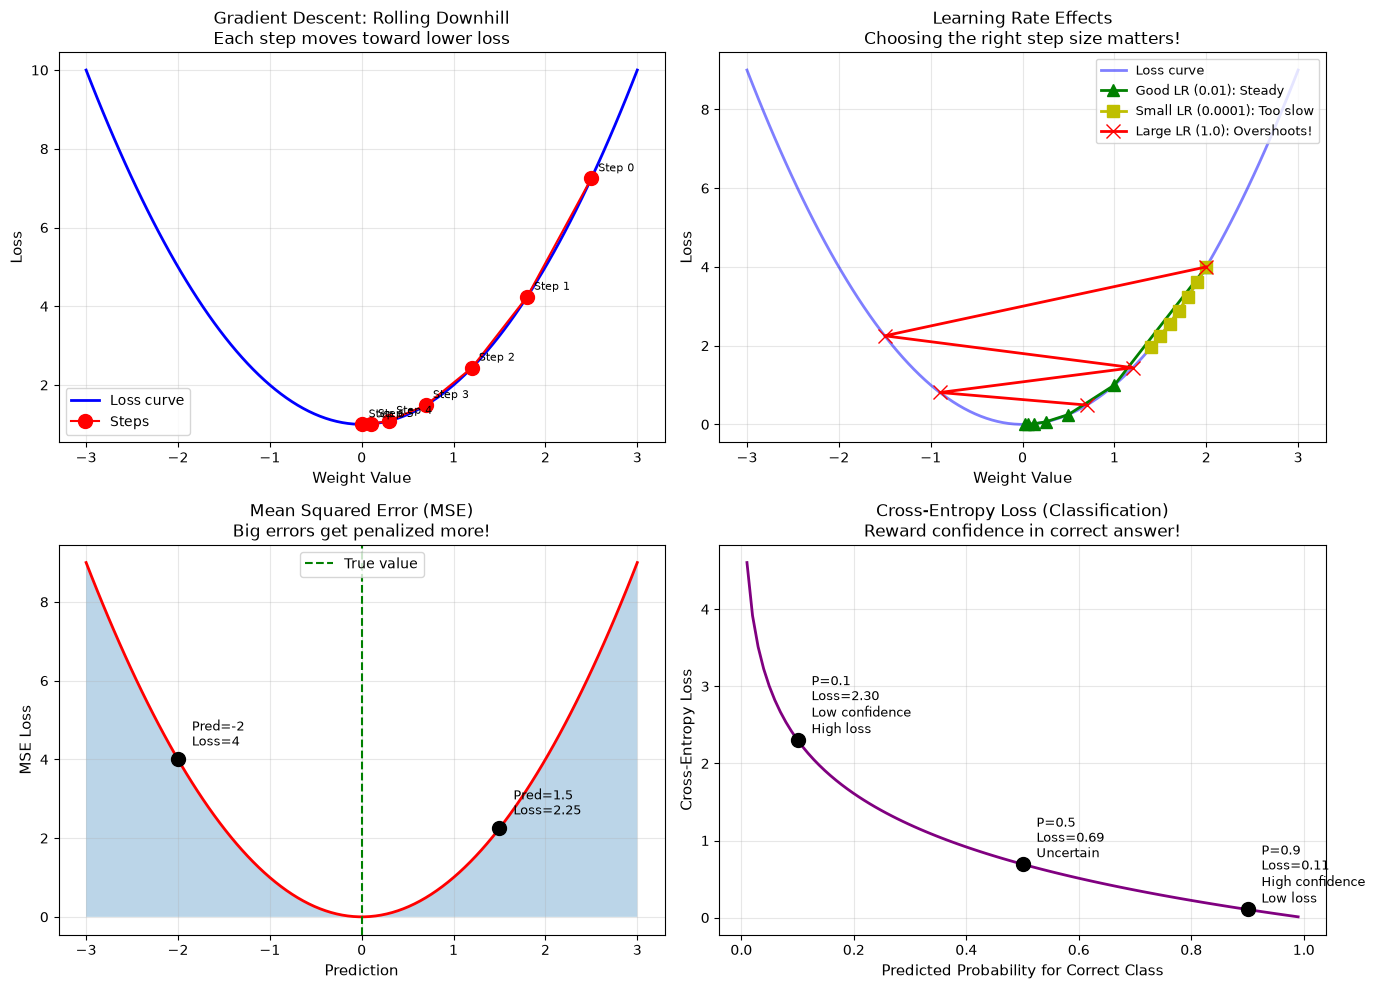

KEY TAKEAWAYS:
  • Gradient descent iteratively improves weights by 'rolling downhill'
  • Learning rate controls step size - not too big, not too small!
  • MSE penalizes big errors more than small ones (squared!)
  • Cross-entropy rewards high confidence in correct predictions


In [17]:
# Visualizing Training Concepts

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ═══════════════════════════════════════════════════════════════════════
# PLOT 1: Gradient Descent Visualization
# ═══════════════════════════════════════════════════════════════════════
ax1 = axes[0, 0]

# Simple loss function (parabola)
x = np.linspace(-3, 3, 100)
y = x**2 + 1  # Loss = weight² + 1 (minimum at weight=0)

ax1.plot(x, y, 'b-', linewidth=2, label='Loss curve')

# Simulate gradient descent steps
steps_x = [2.5, 1.8, 1.2, 0.7, 0.3, 0.1, 0.0]
steps_y = [s**2 + 1 for s in steps_x]
ax1.plot(steps_x, steps_y, 'ro-', markersize=10, label='Steps')

# Add step numbers
for i, (sx, sy) in enumerate(zip(steps_x, steps_y)):
    ax1.annotate(f'Step {i}', (sx, sy), textcoords="offset points",
                 xytext=(5, 5), fontsize=8)

ax1.set_xlabel('Weight Value', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Gradient Descent: Rolling Downhill\nEach step moves toward lower loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════════════════
# PLOT 2: Learning Rate Comparison
# ═══════════════════════════════════════════════════════════════════════
ax2 = axes[0, 1]

x = np.linspace(-3, 3, 100)
y = x**2
ax2.plot(x, y, 'b-', linewidth=2, alpha=0.5, label='Loss curve')

# Good learning rate - smooth progress
good_lr_x = [2.0, 1.0, 0.5, 0.25, 0.12, 0.06, 0.03]
good_lr_y = [g**2 for g in good_lr_x]
ax2.plot(good_lr_x, good_lr_y, 'g^-', markersize=8, linewidth=2,
         label='Good LR (0.01): Steady')

# Too small learning rate
small_lr_x = [2.0, 1.9, 1.8, 1.7, 1.6, 1.5, 1.4]
small_lr_y = [s**2 for s in small_lr_x]
ax2.plot(small_lr_x, small_lr_y, 'ys-', markersize=8, linewidth=2,
         label='Small LR (0.0001): Too slow')

# Too large learning rate - overshoots
large_lr_x = [2.0, -1.5, 1.2, -0.9, 0.7]
large_lr_y = [l**2 for l in large_lr_x]
ax2.plot(large_lr_x, large_lr_y, 'rx-', markersize=10, linewidth=2,
         label='Large LR (1.0): Overshoots!')

ax2.set_xlabel('Weight Value', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.set_title('Learning Rate Effects\nChoosing the right step size matters!', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════════════════
# PLOT 3: MSE Loss Example
# ═══════════════════════════════════════════════════════════════════════
ax3 = axes[1, 0]

# Example: true value = 0, predictions vary
true_value = 0
predictions = np.linspace(-3, 3, 100)
mse = (predictions - true_value) ** 2

ax3.plot(predictions, mse, 'r-', linewidth=2)
ax3.axvline(x=0, color='green', linestyle='--', label='True value')
ax3.fill_between(predictions, 0, mse, alpha=0.3)

# Mark specific errors
for pred, color in [(-2, 'blue'), (1.5, 'orange')]:
    error = (pred - true_value) ** 2
    ax3.plot(pred, error, 'ko', markersize=10)
    ax3.annotate(f'Pred={pred}\nLoss={error}', (pred, error),
                textcoords="offset points", xytext=(10, 10), fontsize=9)

ax3.set_xlabel('Prediction', fontsize=11)
ax3.set_ylabel('MSE Loss', fontsize=11)
ax3.set_title('Mean Squared Error (MSE)\nBig errors get penalized more!', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════════════════
# PLOT 4: Cross-Entropy Loss
# ═══════════════════════════════════════════════════════════════════════
ax4 = axes[1, 1]

# Cross-entropy for correct class
p = np.linspace(0.01, 0.99, 100)
cross_entropy = -np.log(p)

ax4.plot(p, cross_entropy, 'purple', linewidth=2)

# Mark key points
points = [(0.1, 'Low confidence\nHigh loss'),
          (0.5, 'Uncertain'),
          (0.9, 'High confidence\nLow loss')]
for prob, label in points:
    loss = -np.log(prob)
    ax4.plot(prob, loss, 'ko', markersize=10)
    ax4.annotate(f'P={prob}\nLoss={loss:.2f}\n{label}', (prob, loss),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

ax4.set_xlabel('Predicted Probability for Correct Class', fontsize=11)
ax4.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax4.set_title('Cross-Entropy Loss (Classification)\nReward confidence in correct answer!', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY TAKEAWAYS:")
print("  • Gradient descent iteratively improves weights by 'rolling downhill'")
print("  • Learning rate controls step size - not too big, not too small!")
print("  • MSE penalizes big errors more than small ones (squared!)")
print("  • Cross-entropy rewards high confidence in correct predictions")

---

# Part 6: Your First Neural Network with Keras

**We've completed the theory! Let's recap everything:**

| Part | Concept | Key Takeaway |
|------|---------|--------------|
| Part 1 | ML vs Deep Learning | DL learns features automatically |
| Part 2 | Perceptrons | weighted sum → bias → activation |
| Part 3 | Hidden Layers | Multiple perceptrons → complex patterns |
| Part 4 | Forward Propagation | How predictions are made |
| Part 5 | Training | How weights are learned (gradient descent) |
| **Part 6** | **Keras** | **Let's build a real one!** |

We understand all the pieces. Now it's time to **put them together and build a real neural network that actually learns!**

---

## Why Keras? (Not Building From Scratch)

You might wonder: "Why not implement everything ourselves?"

We could... but it would take hundreds of lines of code just for basic functionality. Instead, we'll use **Keras** - a library that handles all the complex math while letting us focus on the interesting parts (architecture and experimentation).

```
WHAT KERAS DOES FOR US:

Without Keras (from scratch):          With Keras:
──────────────────────────────         ────────────────────────────
200+ lines of code                     ~10 lines of code
Manual gradient calculations           Automatic differentiation
Your own optimization loop             Built-in optimizers
CPU only (slow)                        GPU support (fast!)
Bugs everywhere                        Battle-tested code

Keras lets us focus on ARCHITECTURE and EXPERIMENTATION,
not on implementing calculus and linear algebra!
```

**Key facts about Keras:**
- Created by François Chollet at Google in 2015
- Now part of TensorFlow (Google's deep learning framework)
- Used by: Google, Netflix, Uber, NASA, CERN
- Perfect for learning AND production systems

---

## The MNIST Dataset: Our Test Case

To test our neural network, we need data. We'll use **MNIST** - the classic "Hello World" of deep learning.

```
MNIST AT A GLANCE:

    What: Handwritten digits (0-9)
    Size: 70,000 images total
          - 60,000 for training
          - 10,000 for testing
    Image size: 28 × 28 = 784 pixels (grayscale)
    Task: Look at image → predict which digit (0-9)

    Example images:
    
    ████████     ░░██░░░░     ████████     ░░░░██░░
    ██░░░░██     ░░██░░░░     ░░░░░░██     ░░░░██░░
    ████████     ░░██░░░░     ████████     ████████
    ░░░░░░██     ░░██░░░░     ██░░░░░░     ░░░░██░░
    ████████     ░░██░░░░     ████████     ░░░░██░░
       "8"         "1"          "5"          "4"
```

**Why MNIST is perfect for learning:**
- Simple enough: trains in minutes, not hours
- Complex enough: requires a real neural network
- Well-studied: we know ~99% accuracy is achievable
- Built into Keras: no downloading needed!

**Our goal:** Build a neural network that can look at a handwritten digit and correctly identify it.

Let's do this!

In [20]:
# ═══════════════════════════════════════════════════════════════════════
# IMPORT TENSORFLOW AND KERAS
# ═══════════════════════════════════════════════════════════════════════

# TensorFlow is Google's deep learning framework
# Keras is the high-level API built on top of TensorFlow

import tensorflow as tf

# From Keras, we need:
from tensorflow.keras import layers, models      # For building networks
from tensorflow.keras.utils import to_categorical  # For one-hot encoding labels
from tensorflow.keras.datasets import mnist       # The MNIST dataset

print("=" * 60)
print("TensorFlow/Keras Setup Complete!")
print("=" * 60)
print(f"\nTensorFlow version: {tf.__version__}")
print(f"\nWhat we imported:")
print(f"  • tensorflow (tf)         - The core deep learning framework")
print(f"  • layers                  - Building blocks (Dense, Flatten, etc.)")
print(f"  • models                  - For creating Sequential models")
print(f"  • to_categorical          - Convert labels to one-hot encoding")
print(f"  • mnist                   - The MNIST dataset")

TensorFlow/Keras Setup Complete!

TensorFlow version: 2.16.2

What we imported:
  • tensorflow (tf)         - The core deep learning framework
  • layers                  - Building blocks (Dense, Flatten, etc.)
  • models                  - For creating Sequential models
  • to_categorical          - Convert labels to one-hot encoding
  • mnist                   - The MNIST dataset


In [21]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 0: LOAD THE MNIST DATASET
# ═══════════════════════════════════════════════════════════════════════

# Keras includes MNIST - it downloads automatically on first use!
# Returns two tuples: (training data, test data)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("=" * 60)
print("MNIST Dataset Loaded!")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"    Training images: {X_train.shape[0]:,}")
print(f"    Test images:     {X_test.shape[0]:,}")
print(f"    Total images:    {X_train.shape[0] + X_test.shape[0]:,}")

print("\n📐 IMAGE DIMENSIONS:")
print(f"    Shape: {X_train.shape[1:]} (height × width)")
print(f"    Total pixels per image: {X_train.shape[1] * X_train.shape[2]}")
print(f"    Color: Grayscale (1 channel)")

print("\n🏷️ LABELS:")
print(f"    Classes: 10 (digits 0-9)")
print(f"    Training label shape: {y_train.shape}")
print(f"    Sample labels: {y_train[:10]}")

print("\n📈 PIXEL VALUES:")
print(f"    Minimum: {X_train.min()} (black)")
print(f"    Maximum: {X_train.max()} (white)")
print(f"    Data type: {X_train.dtype}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
MNIST Dataset Loaded!

📊 DATASET OVERVIEW:
    Training images: 60,000
    Test images:     10,000
    Total images:    70,000

📐 IMAGE DIMENSIONS:
    Shape: (28, 28) (height × width)
    Total pixels per image: 784
    Color: Grayscale (1 channel)

🏷️ LABELS:
    Classes: 10 (digits 0-9)
    Training label shape: (60000,)
    Sample labels: [5 0 4 1 9 2 1 3 1 4]

📈 PIXEL VALUES:
    Minimum: 0 (black)
    Maximum: 255 (white)
    Data type: uint8


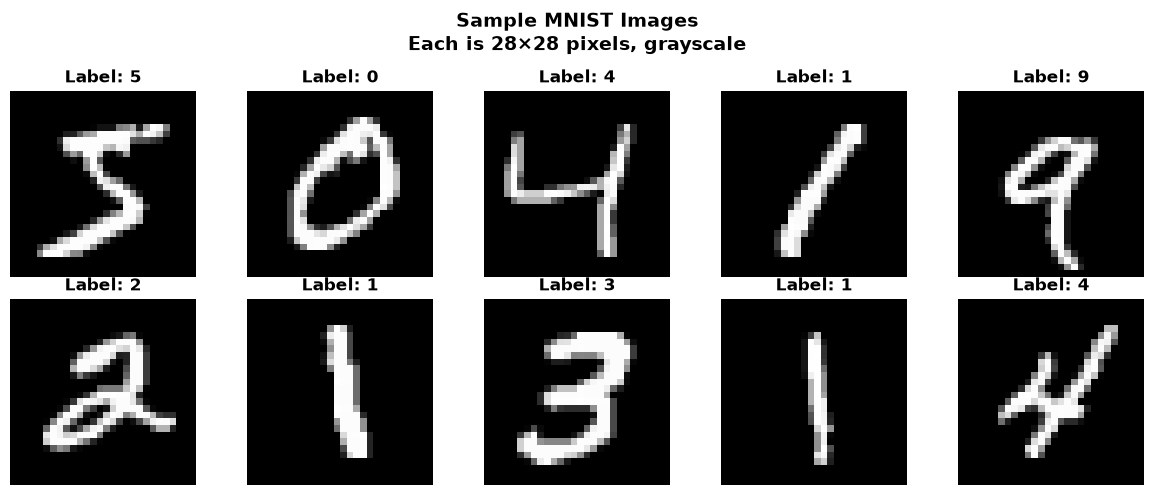


ZOOMING INTO ONE IMAGE

Image #0, Label: 5
Shape: (28, 28)

Pixel values (first 5 rows, middle columns):
[[  0   0   3  18  18  18 126 136]
 [ 94 154 170 253 253 253 253 253]
 [253 253 253 253 253 253 253 251]
 [253 253 253 253 198 182 247 241]
 [107 253 253 205  11   0  43 154]]

  0 = black (no ink)
  255 = white (full ink)
  Values in between = shades of gray


In [22]:
# ═══════════════════════════════════════════════════════════════════════
# VISUALIZE MNIST SAMPLES
# ═══════════════════════════════════════════════════════════════════════

# Let's see what these handwritten digits look like!

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    # Show the image (grayscale colormap)
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample MNIST Images\nEach is 28×28 pixels, grayscale',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show one image in detail
print("\n" + "=" * 60)
print("ZOOMING INTO ONE IMAGE")
print("=" * 60)

sample_idx = 0
print(f"\nImage #{sample_idx}, Label: {y_train[sample_idx]}")
print(f"Shape: {X_train[sample_idx].shape}")
print(f"\nPixel values (first 5 rows, middle columns):")
print(X_train[sample_idx][5:10, 10:18])  # Show a portion
print("\n  0 = black (no ink)")
print("  255 = white (full ink)")
print("  Values in between = shades of gray")

## Step 1: Preprocess the Data

Before feeding data to a neural network, we need to prepare it properly. Two key steps:

### 1. Normalization: Scale pixel values to [0, 1]

```
WHY NORMALIZE?

Neural networks learn better when inputs are small and centered:

Before normalization:          After normalization:
pixel values: 0 to 255         pixel values: 0 to 1

    ████████  = 255            ████████  = 1.0
    ░░░░░░░░  = 0              ░░░░░░░░  = 0.0
    ████░░░░  = 127            ████░░░░  = 0.5

BENEFITS:
1. Prevents large gradients that make training unstable
2. All features on same scale (fair comparison)
3. Faster convergence during training

HOW: Simply divide by 255 (the maximum pixel value)
```

### 2. One-Hot Encoding: Convert labels to vector format

```
WHY ONE-HOT ENCODING?

Our network outputs 10 probabilities (one per digit).
Labels need to be in the same format for comparison!

Before one-hot:                After one-hot:
y = 3                         y = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
(just a number)                    0  1  2  3  4  5  6  7  8  9
                                         ↑
                                      class 3

Network output:               Label (one-hot):
[0.01, 0.02, 0.01,           [0,    0,    0,
 0.90, 0.01, 0.02,            1,    0,    0,     ← Can compute loss!
 0.01, 0.01, 0.01]            0,    0,    0,    0]

Cross-entropy loss compares these two vectors!
```

In [23]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 1: PREPROCESS THE DATA
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("PREPROCESSING THE DATA")
print("=" * 60)

# ─────────────────────────────────────────────────────────────────────────
# PART A: NORMALIZE PIXEL VALUES (0-255 → 0-1)
# ─────────────────────────────────────────────────────────────────────────

print("\n📏 NORMALIZATION:")
print(f"\n    Before:")
print(f"    Min pixel value: {X_train.min()}")
print(f"    Max pixel value: {X_train.max()}")
print(f"    Data type: {X_train.dtype}")

# Normalize: divide by 255 to get values between 0 and 1
# Also convert to float32 (standard for neural networks)
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"\n    After (divided by 255):")
print(f"    Min pixel value: {X_train_normalized.min()}")
print(f"    Max pixel value: {X_train_normalized.max()}")
print(f"    Data type: {X_train_normalized.dtype}")

# ─────────────────────────────────────────────────────────────────────────
# PART B: ONE-HOT ENCODE LABELS
# ─────────────────────────────────────────────────────────────────────────

print("\n" + "-" * 60)
print("🏷️ ONE-HOT ENCODING:")

print(f"\n    Before (integer labels):")
print(f"    Shape: {y_train.shape}")
print(f"    First 5 labels: {y_train[:5]}")
print(f"    Example: y[0] = {y_train[0]} (just the digit)")

# to_categorical converts integers to one-hot vectors
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f"\n    After (one-hot vectors):")
print(f"    Shape: {y_train_encoded.shape}  ← (samples, classes)")
print(f"    First label: {y_train[0]}")
print(f"    One-hot:     {y_train_encoded[0]}")
print(f"                  0  1  2  3  4  5  6  7  8  9")
print(f"                        ↑")
print(f"                     1.0 at position {y_train[0]}")

print("\n" + "=" * 60)
print("✅ Data preprocessing complete!")
print("=" * 60)

PREPROCESSING THE DATA

📏 NORMALIZATION:

    Before:
    Min pixel value: 0
    Max pixel value: 255
    Data type: uint8

    After (divided by 255):
    Min pixel value: 0.0
    Max pixel value: 1.0
    Data type: float32

------------------------------------------------------------
🏷️ ONE-HOT ENCODING:

    Before (integer labels):
    Shape: (60000,)
    First 5 labels: [5 0 4 1 9]
    Example: y[0] = 5 (just the digit)

    After (one-hot vectors):
    Shape: (60000, 10)  ← (samples, classes)
    First label: 5
    One-hot:     [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
                  0  1  2  3  4  5  6  7  8  9
                        ↑
                     1.0 at position 5

✅ Data preprocessing complete!


## Step 2: Build the Neural Network

Now we define our architecture - translating the diagrams from Part 3 into actual code!

```
OUR NETWORK ARCHITECTURE:

    INPUT LAYER              HIDDEN LAYER              OUTPUT LAYER
    (Flatten)                (Dense + ReLU)            (Dense + Softmax)
    
    28×28 image              128 neurons               10 neurons
        │                         │                         │
        ▼                         ▼                         ▼
    ┌─────────┐              ┌─────────┐              ┌─────────┐
    │ Flatten │              │ Dense   │              │ Dense   │
    │ 28×28   │─────────────►│   128   │─────────────►│   10    │──► Prediction
    │ → 784   │              │  ReLU   │              │ Softmax │
    └─────────┘              └─────────┘              └─────────┘
    
    WHY EACH LAYER?
    
    1. Flatten: Convert 2D image (28×28) to 1D vector (784)
       - Dense layers need 1D input
       - Think: unrolling the image into a single row
    
    2. Dense(128, relu): The hidden layer
       - 128 neurons learn intermediate features
       - ReLU activation (from Part 2!)
       - Each neuron connects to ALL 784 inputs
    
    3. Dense(10, softmax): The output layer
       - 10 neurons (one per digit class)
       - Softmax activation → probabilities that sum to 1
       - Highest probability = predicted digit
```

### Keras Sequential API

We'll use the **Sequential** model - layers stacked in order, one after another.

```python
# The pattern:
model = models.Sequential([
    layers.SomeLayer(...),    # First layer
    layers.AnotherLayer(...), # Second layer
    layers.OutputLayer(...)   # Last layer
])
```

In [24]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 2: BUILD THE NEURAL NETWORK
# ═══════════════════════════════════════════════════════════════════════

# This is the EXACT code you'll use in Exercise 3!

print("=" * 60)
print("BUILDING THE NEURAL NETWORK")
print("=" * 60)

# Create a Sequential model (layers in order)
model = models.Sequential([

    # ─────────────────────────────────────────────────────────────────────
    # INPUT: Declare the shape of one sample
    # ─────────────────────────────────────────────────────────────────────
    # Each image is 28×28 grayscale pixels
    layers.Input(shape=(28, 28)),

    # ─────────────────────────────────────────────────────────────────────
    # LAYER 1: Flatten
    # ─────────────────────────────────────────────────────────────────────
    # Convert 2D image (28×28) to 1D vector (784)
    # This is required because Dense layers expect 1D input
    layers.Flatten(),

    # ─────────────────────────────────────────────────────────────────────
    # LAYER 2: Hidden Dense Layer
    # ─────────────────────────────────────────────────────────────────────
    # 128 neurons, fully connected to all 784 inputs
    # ReLU activation: max(0, x) - the modern standard for hidden layers!
    # Each neuron learns a different pattern in the data
    layers.Dense(128, activation='relu'),

    # ─────────────────────────────────────────────────────────────────────
    # LAYER 3: Output Dense Layer
    # ─────────────────────────────────────────────────────────────────────
    # 10 neurons - one for each digit class (0-9)
    # Softmax activation: converts outputs to probabilities summing to 1
    # The neuron with highest probability = predicted digit
    layers.Dense(10, activation='softmax')

])

print("\n✅ Model created!")
print("\n" + "-" * 60)
print("MODEL ARCHITECTURE (model.summary()):")
print("-" * 60)

# Display the model architecture
model.summary()

print("\n" + "-" * 60)
print("UNDERSTANDING THE OUTPUT:")
print("-" * 60)
print("""
Layer (type)          Output Shape       Param #
─────────────────────────────────────────────────
flatten               (None, 784)        0
                      ↑
                      28×28 = 784 pixels flattened

dense (hidden)        (None, 128)        100,480
                      ↑                   ↑
                      128 neurons         784×128 + 128 biases

dense_1 (output)      (None, 10)         1,290
                      ↑                   ↑
                      10 classes          128×10 + 10 biases

Total params: 101,770 (weights + biases to learn!)
""")

BUILDING THE NEURAL NETWORK

✅ Model created!

------------------------------------------------------------
MODEL ARCHITECTURE (model.summary()):
------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


------------------------------------------------------------
UNDERSTANDING THE OUTPUT:
------------------------------------------------------------

Layer (type)          Output Shape       Param #
─────────────────────────────────────────────────
flatten               (None, 784)        0
                      ↑
                      28×28 = 784 pixels flattened

dense (hidden)        (None, 128)        100,480
                      ↑                   ↑
                      128 neurons         784×128 + 128 biases

dense_1 (output)      (None, 10)         1,290
                      ↑                   ↑
                      10 classes          128×10 + 10 biases

Total params: 101,770 (weights + biases to learn!)



In [25]:
# Visualize our architecture
print("\nVisual representation:")
print("""
    INPUT (28x28=784)     HIDDEN (128)        OUTPUT (10)

         ○                    ○
         ○                    ○
         ○       Flatten      ○                  ○ → digit 0
         ○    ──────────►     ○     Dense        ○ → digit 1
        ...       +          ...  ──────────►   ...
         ○      Dense         ○                  ○ → digit 8
         ○      (ReLU)        ○    (Softmax)     ○ → digit 9
         ○                    ○

    (784 inputs)          (128 neurons)       (10 probabilities)
""")

# Count parameters
print(f"Total trainable parameters: {model.count_params():,}")
print(f"  Layer 1: 784 × 128 + 128 biases = {784*128 + 128:,}")
print(f"  Layer 2: 128 × 10 + 10 biases = {128*10 + 10:,}")


Visual representation:

    INPUT (28x28=784)     HIDDEN (128)        OUTPUT (10)

         ○                    ○
         ○                    ○
         ○       Flatten      ○                  ○ → digit 0
         ○    ──────────►     ○     Dense        ○ → digit 1
        ...       +          ...  ──────────►   ...
         ○      Dense         ○                  ○ → digit 8
         ○      (ReLU)        ○    (Softmax)     ○ → digit 9
         ○                    ○

    (784 inputs)          (128 neurons)       (10 probabilities)

Total trainable parameters: 101,770
  Layer 1: 784 × 128 + 128 biases = 100,480
  Layer 2: 128 × 10 + 10 biases = 1,290


## Step 3: Compile the Model

Before training, we need to configure **how** the model will learn. This is called "compiling."

```
THREE THINGS TO SPECIFY:

1. OPTIMIZER: How to update weights
   ─────────────────────────────────────────────────────────────
   Optimizer = the algorithm that adjusts weights
   
   'adam' (Adaptive Moment Estimation):
   - Automatically adjusts learning rate during training
   - Works well for most problems
   - Default choice for beginners AND experts
   
   Other options: 'sgd' (simpler), 'rmsprop', 'adagrad'

2. LOSS FUNCTION: What to minimize
   ─────────────────────────────────────────────────────────────
   Loss = measure of how wrong predictions are (from Part 5!)
   
   'categorical_crossentropy':
   - For multi-class classification with one-hot labels
   - Penalizes wrong predictions heavily
   - Higher penalty for confident wrong answers
   
   Other options: 'binary_crossentropy' (2 classes), 'mse' (regression)

3. METRICS: What to track during training
   ─────────────────────────────────────────────────────────────
   Metrics = numbers to display during training (not used for learning!)
   
   ['accuracy']:
   - Percentage of correct predictions
   - Human-understandable (unlike loss values)
   
   Other options: 'precision', 'recall', 'AUC'
```

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 3: COMPILE THE MODEL
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("COMPILING THE MODEL")
print("=" * 60)

# Configure how the model will learn
model.compile(
    # OPTIMIZER: How to update weights during training
    # 'adam' = Adaptive Moment Estimation (best default choice)
    optimizer='adam',

    # LOSS: What to minimize (from Part 5!)
    # 'categorical_crossentropy' = for multi-class classification
    loss='categorical_crossentropy',

    # METRICS: What to track (for us to see, not for training)
    # 'accuracy' = percentage of correct predictions
    metrics=['accuracy']
)

print("\n✅ Model compiled!")

print("\n" + "-" * 60)
print("CONFIGURATION SUMMARY:")
print("-" * 60)

print("""
┌─────────────────────────────────────────────────────────────┐
│  OPTIMIZER: 'adam'                                          │
│      • Adaptive learning rate                               │
│      • Works well for most problems                         │
│      • Adjusts step size automatically                      │
├─────────────────────────────────────────────────────────────┤
│  LOSS: 'categorical_crossentropy'                           │
│      • For multi-class classification (10 digits)           │
│      • Compares predicted probabilities to one-hot labels   │
│      • Heavily penalizes confident wrong answers            │
├─────────────────────────────────────────────────────────────┤
│  METRICS: ['accuracy']                                      │
│      • Shows % correct during training                      │
│      • Human-readable progress indicator                    │
│      • NOT used for weight updates (just for display)       │
└─────────────────────────────────────────────────────────────┘
""")

print("Now the model is ready to learn! Next: Training")

COMPILING THE MODEL

✅ Model compiled!

------------------------------------------------------------
CONFIGURATION SUMMARY:
------------------------------------------------------------

┌─────────────────────────────────────────────────────────────┐
│  OPTIMIZER: 'adam'                                          │
│      • Adaptive learning rate                               │
│      • Works well for most problems                         │
│      • Adjusts step size automatically                      │
├─────────────────────────────────────────────────────────────┤
│  LOSS: 'categorical_crossentropy'                           │
│      • For multi-class classification (10 digits)           │
│      • Compares predicted probabilities to one-hot labels   │
│      • Heavily penalizes confident wrong answers            │
├─────────────────────────────────────────────────────────────┤
│  METRICS: ['accuracy']                                      │
│      • Shows % correct during training      

## Step 4: Train the Model

This is where the magic happens! The model will:
1. See training data
2. Make predictions (forward pass)
3. Measure errors (loss)
4. Adjust weights (backpropagation)
5. Repeat thousands of times!

```
THE .fit() METHOD:

model.fit(
    X_train,              # Training images
    y_train,              # Training labels
    epochs=5,             # How many times to see ALL training data
    batch_size=32,        # Images per weight update
    validation_split=0.1  # Hold out 10% for validation
)

KEY PARAMETERS EXPLAINED:

EPOCHS (epochs=5):
    ─────────────────────────────────────────────────────────
    1 epoch = model sees ALL training images once
    More epochs = more learning opportunities
    BUT too many epochs → overfitting (memorizing, not learning)
    
    Epoch 1: Model is clueless, makes random guesses
    Epoch 2: Model starts recognizing some patterns
    ...
    Epoch 5: Model has seen each image 5 times, much smarter!

BATCH SIZE (batch_size=32):
    ─────────────────────────────────────────────────────────
    Instead of updating weights after EACH image,
    we update after every BATCH of images.
    
    Why batches?
    - Faster than one-at-a-time (parallelization)
    - More stable than full dataset (too slow)
    - 32 is a common default (powers of 2 for GPU efficiency)
    
    60,000 images ÷ 32 = 1,875 weight updates per epoch

VALIDATION SPLIT (validation_split=0.1):
    ─────────────────────────────────────────────────────────
    Hold out 10% of training data to check progress.
    - Model trains on 90% (54,000 images)
    - Validates on 10% (6,000 images)
    - Validation accuracy tells us if model generalizes!
```

In [27]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 4: TRAIN THE MODEL
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("TRAINING THE NEURAL NETWORK")
print("=" * 60)

print("""
What's about to happen:
    • Model will see 54,000 training images (90% of 60,000)
    • It will go through all images 5 times (5 epochs)
    • Weights update every 32 images (batch_size)
    • We validate on 6,000 held-out images after each epoch

Watch the accuracy improve with each epoch!
""")

print("-" * 60)

# Train the model!
history = model.fit(
    X_train_normalized,      # Training images (normalized!)
    y_train_encoded,         # Training labels (one-hot encoded!)
    epochs=5,                # See all data 5 times
    batch_size=32,           # Update weights every 32 images
    validation_split=0.1,    # Use 10% for validation
    verbose=1                # Show progress bar
)

print("-" * 60)
print("\n✅ Training complete!")

print("\n" + "-" * 60)
print("WHAT THE OUTPUT MEANS:")
print("-" * 60)
print("""
loss: 0.25        → Cross-entropy loss on training data (lower = better)
accuracy: 0.93    → 93% of training predictions correct
val_loss: 0.15    → Cross-entropy loss on validation data
val_accuracy: 0.97 → 97% of validation predictions correct

GOOD SIGNS:
    • Loss decreasing each epoch ✓
    • Accuracy increasing each epoch ✓
    • val_accuracy close to accuracy (not overfitting) ✓
""")

TRAINING THE NEURAL NETWORK

What's about to happen:
    • Model will see 54,000 training images (90% of 60,000)
    • It will go through all images 5 times (5 epochs)
    • Weights update every 32 images (batch_size)
    • We validate on 6,000 held-out images after each epoch

Watch the accuracy improve with each epoch!

------------------------------------------------------------
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9219 - loss: 0.2719 - val_accuracy: 0.9615 - val_loss: 0.1363
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9646 - loss: 0.1195 - val_accuracy: 0.9752 - val_loss: 0.0904
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9758 - loss: 0.0809 - val_accuracy: 0.9753 - val_loss: 0.0807
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9810 - loss: 0.0603 - val_accuracy: 0.9787 - val_loss: 0.0750
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9861 - loss: 0.0456 - val_accura

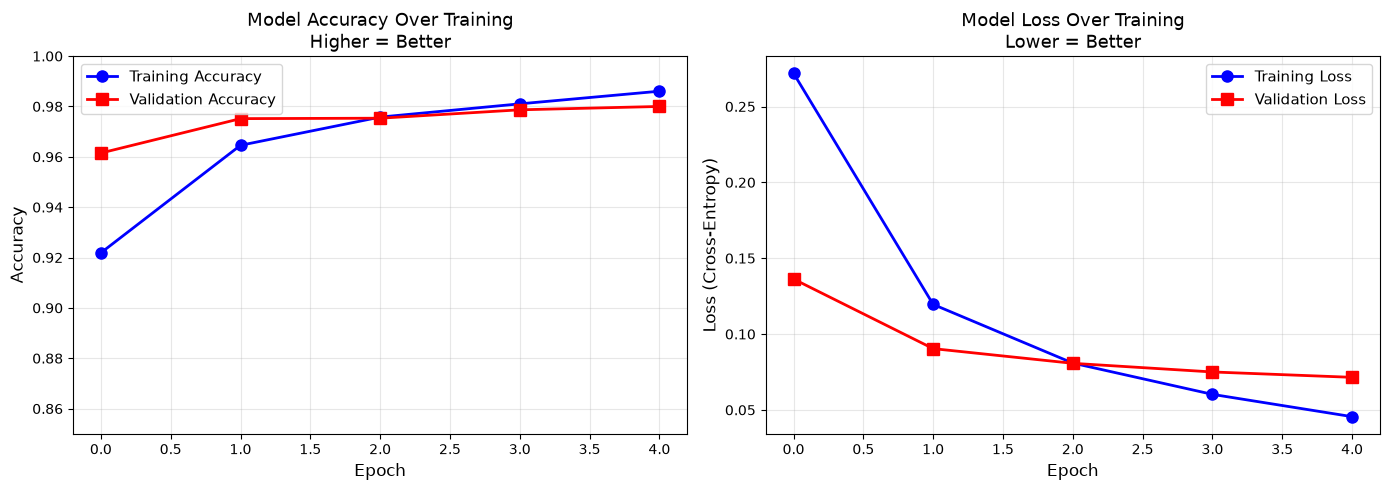

READING THESE CHARTS:

GOOD TRAINING (what we want):
    • Accuracy goes UP, Loss goes DOWN
    • Training and Validation curves stay CLOSE together
    • Both curves flatten out (model has learned)

WARNING SIGNS:
    • Training accuracy >> Validation accuracy = OVERFITTING
      (model memorized training data, doesn't generalize)
    • Curves going up and down = unstable training
      (learning rate might be too high)



In [28]:
# ═══════════════════════════════════════════════════════════════════════
# VISUALIZE TRAINING PROGRESS
# ═══════════════════════════════════════════════════════════════════════

# The 'history' object contains metrics from each epoch
# Let's visualize how the model learned!

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─────────────────────────────────────────────────────────────────────────
# PLOT 1: ACCURACY OVER TIME
# ─────────────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(history.history['accuracy'], 'b-o', linewidth=2, markersize=8,
         label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], 'r-s', linewidth=2, markersize=8,
         label='Validation Accuracy')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Over Training\nHigher = Better', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.85, 1.0)

# ─────────────────────────────────────────────────────────────────────────
# PLOT 2: LOSS OVER TIME
# ─────────────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(history.history['loss'], 'b-o', linewidth=2, markersize=8,
         label='Training Loss')
ax2.plot(history.history['val_loss'], 'r-s', linewidth=2, markersize=8,
         label='Validation Loss')

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax2.set_title('Model Loss Over Training\nLower = Better', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("READING THESE CHARTS:")
print("=" * 60)
print("""
GOOD TRAINING (what we want):
    • Accuracy goes UP, Loss goes DOWN
    • Training and Validation curves stay CLOSE together
    • Both curves flatten out (model has learned)

WARNING SIGNS:
    • Training accuracy >> Validation accuracy = OVERFITTING
      (model memorized training data, doesn't generalize)
    • Curves going up and down = unstable training
      (learning rate might be too high)
""")

## Step 5: Evaluate on Test Set

The honest exam: 10,000 images the model has **never seen** - not in training, not in validation. Test accuracy is the number that actually matters.

In [29]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 5: EVALUATE ON TEST SET
# ═══════════════════════════════════════════════════════════════════════

# The TRUE test: How well does our model work on data it's NEVER seen?
# We held back 10,000 images that were never used in training!

print("=" * 60)
print("EVALUATING ON TEST SET (Never Seen During Training!)")
print("=" * 60)

# Evaluate returns [loss, accuracy]
test_loss, test_accuracy = model.evaluate(
    X_test_normalized,
    y_test_encoded,
    verbose=0  # Quiet mode (no progress bar)
)

print(f"""
┌────────────────────────────────────────────────────────────┐
│                    TEST SET RESULTS                         │
├────────────────────────────────────────────────────────────┤
│                                                            │
│   Test Accuracy:  {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)                   │
│   Test Loss:      {test_loss:.4f}                                  │
│                                                            │
├────────────────────────────────────────────────────────────┤
│   Out of {len(X_test):,} test images:                          │
│      ✓ Correctly classified:   {int(test_accuracy * len(X_test)):,}                  │
│      ✗ Incorrectly classified: {int((1-test_accuracy) * len(X_test)):,}                    │
│                                                            │
└────────────────────────────────────────────────────────────┘
""")

print("🎯 INTERPRETATION:")
print(f"   Our simple neural network correctly identifies")
print(f"   {test_accuracy*100:.1f}% of handwritten digits it's never seen!")
print(f"\n   This is quite good for a first network!")
print(f"   State-of-the-art CNNs can achieve 99.7%+ accuracy.")

EVALUATING ON TEST SET (Never Seen During Training!)

┌────────────────────────────────────────────────────────────┐
│                    TEST SET RESULTS                         │
├────────────────────────────────────────────────────────────┤
│                                                            │
│   Test Accuracy:  0.9777  (97.77%)                   │
│   Test Loss:      0.0740                                  │
│                                                            │
├────────────────────────────────────────────────────────────┤
│   Out of 10,000 test images:                          │
│      ✓ Correctly classified:   9,776                  │
│      ✗ Incorrectly classified: 223                    │
│                                                            │
└────────────────────────────────────────────────────────────┘

🎯 INTERPRETATION:
   Our simple neural network correctly identifies
   97.8% of handwritten digits it's never seen!

   This is quite good for a fi

## Step 6: Make Predictions and Visualize

`model.predict()` runs forward propagation on new images and returns 10 softmax probabilities per image. Time to watch the network read real handwriting.

MAKING PREDICTIONS ON TEST IMAGES

Prediction shape: (10000, 10)
  → 10,000 images × 10 probability values each

Sample prediction (first image):
  Probabilities: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  Predicted digit: 7 (highest probability)
  Actual digit: 7

------------------------------------------------------------
VISUALIZING RANDOM PREDICTIONS
------------------------------------------------------------


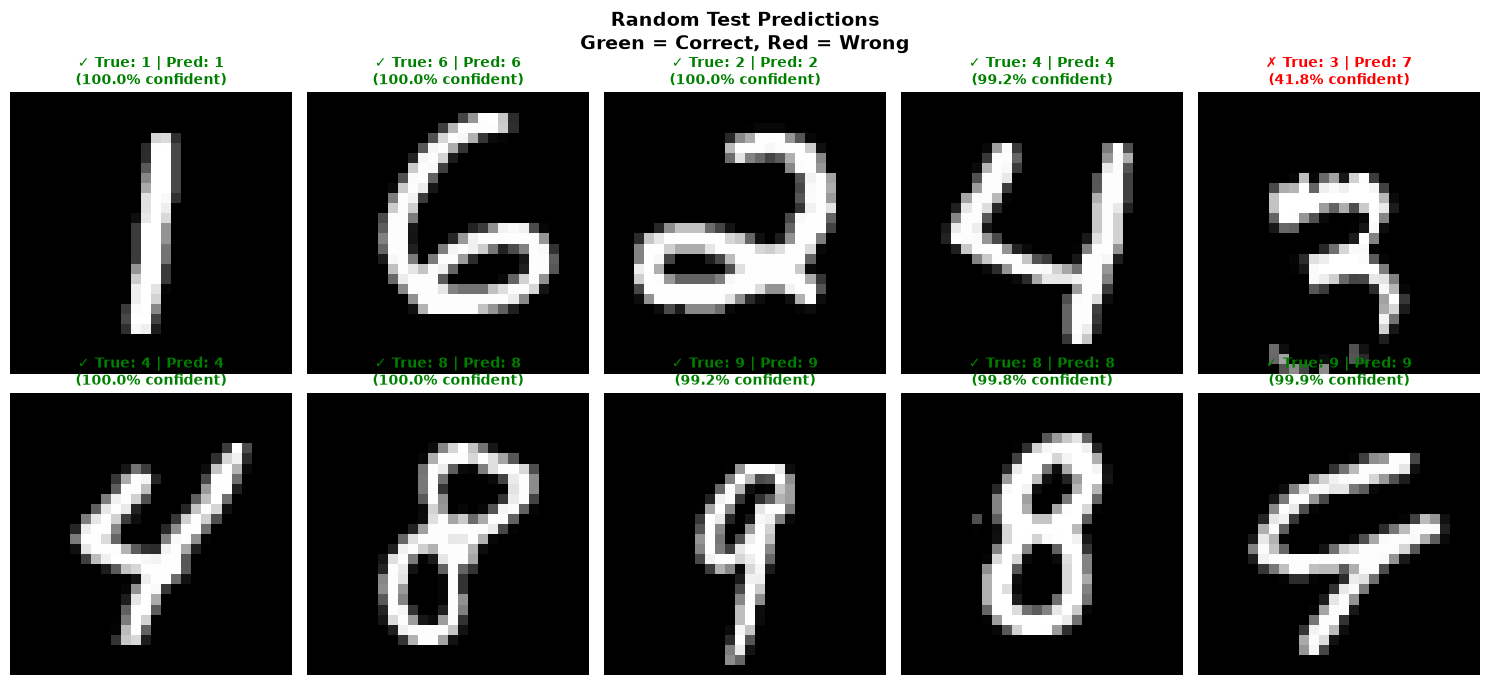

In [30]:
# ═══════════════════════════════════════════════════════════════════════
# STEP 6: MAKE PREDICTIONS AND VISUALIZE
# ═══════════════════════════════════════════════════════════════════════

# Let's see the model in action!
# model.predict() runs forward propagation and returns probabilities

print("=" * 60)
print("MAKING PREDICTIONS ON TEST IMAGES")
print("=" * 60)

# Get predictions for ALL test images (this runs forward propagation!)
predictions = model.predict(X_test_normalized, verbose=0)

print(f"\nPrediction shape: {predictions.shape}")
print(f"  → 10,000 images × 10 probability values each")
print(f"\nSample prediction (first image):")
print(f"  Probabilities: {predictions[0].round(3)}")
print(f"  Predicted digit: {np.argmax(predictions[0])} (highest probability)")
print(f"  Actual digit: {y_test[0]}")

# ─────────────────────────────────────────────────────────────────────────
# Visualize random predictions
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 60)
print("VISUALIZING RANDOM PREDICTIONS")
print("-" * 60)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, ax in enumerate(axes.flat):
    # Get a random test image
    idx = np.random.randint(0, len(X_test))

    # Show image
    ax.imshow(X_test[idx], cmap='gray')

    # Get prediction
    pred_probs = predictions[idx]
    pred_digit = np.argmax(pred_probs)
    pred_confidence = pred_probs[pred_digit] * 100
    true_digit = y_test[idx]

    # Color based on correct/incorrect
    is_correct = pred_digit == true_digit
    color = 'green' if is_correct else 'red'
    symbol = '✓' if is_correct else '✗'

    ax.set_title(f'{symbol} True: {true_digit} | Pred: {pred_digit}\n({pred_confidence:.1f}% confident)',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Random Test Predictions\nGreen = Correct, Red = Wrong',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

DETAILED PREDICTION BREAKDOWN

Image index: 0
True label: 7
Predicted: 7
Confidence: 99.98%


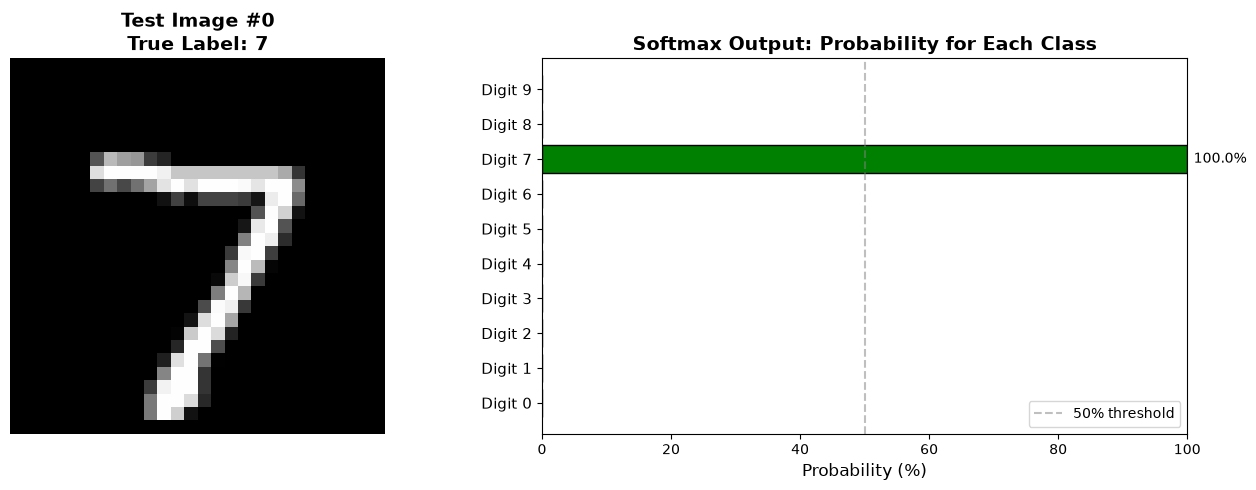


------------------------------------------------------------
WHAT THE SOFTMAX OUTPUT TELLS US:
------------------------------------------------------------

The network outputs 10 probabilities (one per digit):

    • All probabilities sum to 100% (that's what softmax does!)
    • The highest probability = the predicted digit
    • High confidence (>90%) = network is sure
    • Low confidence (<50%) = network is uncertain

This is the FINAL step of forward propagation!
Input → Hidden layers → Softmax → Prediction



In [31]:
# ═══════════════════════════════════════════════════════════════════════
# DETAILED PREDICTION BREAKDOWN
# ═══════════════════════════════════════════════════════════════════════

# Let's see exactly what the softmax output looks like for one image
# Remember: softmax gives us probabilities for EACH digit class!

print("=" * 60)
print("DETAILED PREDICTION BREAKDOWN")
print("=" * 60)

# Pick a specific test image
idx = 0
img = X_test[idx]
true_label = y_test[idx]
pred_probs = predictions[idx]
pred_digit = np.argmax(pred_probs)

print(f"\nImage index: {idx}")
print(f"True label: {true_label}")
print(f"Predicted: {pred_digit}")
print(f"Confidence: {pred_probs[pred_digit]*100:.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─────────────────────────────────────────────────────────────────────────
# LEFT: The actual image
# ─────────────────────────────────────────────────────────────────────────
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Test Image #{idx}\nTrue Label: {true_label}', fontsize=14, fontweight='bold')
axes[0].axis('off')

# ─────────────────────────────────────────────────────────────────────────
# RIGHT: Softmax probabilities (bar chart)
# ─────────────────────────────────────────────────────────────────────────
# Color bars: green for correct class, red for predicted if wrong
colors = []
for i in range(10):
    if i == true_label and i == pred_digit:
        colors.append('green')  # Correct!
    elif i == pred_digit:
        colors.append('red')    # Wrong prediction
    elif i == true_label:
        colors.append('orange') # True class (if missed)
    else:
        colors.append('lightblue')  # Other classes

bars = axes[1].barh(range(10), pred_probs * 100, color=colors, edgecolor='black')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f'Digit {i}' for i in range(10)], fontsize=11)
axes[1].set_xlabel('Probability (%)', fontsize=12)
axes[1].set_title('Softmax Output: Probability for Each Class', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 100)

# Add probability labels on bars
for i, (bar, prob) in enumerate(zip(bars, pred_probs)):
    if prob > 0.01:  # Only label significant probabilities
        axes[1].text(prob * 100 + 1, i, f'{prob*100:.1f}%', va='center', fontsize=10)

axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n" + "-" * 60)
print("WHAT THE SOFTMAX OUTPUT TELLS US:")
print("-" * 60)
print("""
The network outputs 10 probabilities (one per digit):

    • All probabilities sum to 100% (that's what softmax does!)
    • The highest probability = the predicted digit
    • High confidence (>90%) = network is sure
    • Low confidence (<50%) = network is uncertain

This is the FINAL step of forward propagation!
Input → Hidden layers → Softmax → Prediction
""")

---

# Summary: Deep Learning Day 1 - Key Concepts

## What You Learned Today

### Part 1: Traditional ML vs Deep Learning
```
Traditional ML:  Raw Data → [YOU pick features] → Model → Prediction
Deep Learning:   Raw Data → [Network learns features] → Prediction
```
- Deep learning automates feature extraction
- Best for images, text, audio where features are unknown
- Traditional ML still better for tabular data with limited samples

### Part 2: The Perceptron
```
Inputs → [Weighted Sum + Bias] → [Activation Function] → Output

Formula: output = activation(w1*x1 + w2*x2 + ... + bias)
```
- Single perceptron = single linear boundary
- Inspired by biological neurons (loosely!)
- Foundation of all neural networks

### Part 3: Activation Functions

| Function | Formula | Use For | Why? |
|----------|---------|---------|------|
| **Step** | 0 or 1 | Historical | Binary on/off |
| **Sigmoid** | 1/(1+e^-x) | Binary output | Smooth probabilities |
| **ReLU** | max(0, x) | Hidden layers | No vanishing gradient! |
| **Softmax** | e^xi/Σe^xj | Multi-class output | Probabilities sum to 1 |

### Part 4: Forward Propagation
```
Layer by layer:
1. Linear: z = W × x + b
2. Activate: a = activation(z)
3. Pass to next layer
4. Repeat until output
```

### Part 5: Training (How Networks Learn)
```
1. Forward pass → prediction
2. Loss function → measure error
3. Backpropagation → compute gradients  
4. Update weights → w_new = w_old - lr × gradient
5. Repeat many times!
```

### Part 6: Keras Workflow
```python
# 1. Build
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 2. Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train
model.fit(X_train, y_train, epochs=5)

# 4. Evaluate
model.evaluate(X_test, y_test)

# 5. Predict
predictions = model.predict(X_new)
```

---

## Connection to Your Exercises

| Exercise | Relevant Part | Key Concept |
|----------|---------------|-------------|
| **Exercise 1** (Quiz) | Parts 1-3 | ML vs DL, ANNs, activations |
| **Exercise 2** (Perceptron) | Part 2 | Weighted sum + step activation |
| **Exercise 3** (Keras) | Part 6 | Build, compile, train, evaluate |
| **Exercise 4** (Forward Prop) | Part 4 | z = wx + b, then activation |
| **Exercise 5** (Backprop) | Part 5 | Gradient descent, chain rule |
| **Exercise 6** (Visualization) | Part 6 | model.predict() and plotting |

---

## Quick Reference: Formulas

```
PERCEPTRON:
z = Σ(wi × xi) + bias
output = activation(z)

ACTIVATION FUNCTIONS:
Step(z)    = 1 if z > 0, else 0
Sigmoid(z) = 1 / (1 + e^(-z))
ReLU(z)    = max(0, z)
Softmax(zi) = e^zi / Σ(e^zj)

TRAINING:
Loss (MSE) = (1/n) × Σ(pred - actual)²
Loss (CE)  = -Σ yi × log(pi)
w_new = w_old - learning_rate × gradient
```

---

## Next Session Preview

- **Convolutional Neural Networks (CNNs):** Better for images!
- **Regularization:** Dropout, L2 to prevent overfitting
- **Hyperparameter tuning:** Finding the best architecture
- **More complex architectures:** Multiple hidden layers